### Parameters

In [1]:
import sys

# Parameters
patient = globals().get("patient", None)
device = globals().get("device", None)
code_identifier = globals().get("exp_identifier", None)
exp_identifier = globals().get("exp_identifier", None)
folder_model_101 = globals().get("folder_model_101", None)
config = globals().get("config", None)

if patient is None:
    patient = 1
if device is None:
    device = "cpu"
if exp_identifier is None:
    sys.path.insert(0, f"./../../")
    exp_identifier = '34'
if code_identifier is None:
    code_identifier = '100'



print(f"[INFO] Training per patient: {patient}    on device: {device}   and experiment: {exp_identifier}")

[INFO] Training per patient: 1    on device: cpu   and experiment: 34


# imports

In [2]:
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import scipy
import pickle
import importlib
import copy
from pathlib import Path
import scipy.io as sio
import openpyxl
from pathlib import Path
import json
import os

from utils_SSM_100 import set_params, ensure_3d, fun_start_controller, fun_start_controller_simple, plot_glucose_insulin, modify_xlsx_row_and_column, FIT_formula, moving_average_online, LowPassFilter

# Rileva dove sei attualmente
current_dir = Path.cwd()
# Se sei dentro code/exp_X, torna alla radice
if "code" in str(current_dir):
    root = current_dir.parent.parent  # Torna a ./
else:
    root = current_dir  # Sei già alla radice
# Define simulation parameters
torch.set_default_dtype(torch.float64)

# Importa i moduli (non le funzioni da dentro)

sys.path.insert(0, f"./code/exp_{code_identifier}") 

import ParametersFunctions_SSM
import models_SSM
import SSMs
import neural_ssm
from torch.utils.data import DataLoader, random_split, Subset, SubsetRandomSampler, Dataset
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch
from dataset import LoadData, SimpleLoadData
# Ricaricare
importlib.reload(models_SSM)
importlib.reload(SSMs)
importlib.reload(neural_ssm)
importlib.reload(ParametersFunctions_SSM)
# Adesso importa quello che ti serve
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss
from SSMs import DualSSM
from neural_ssm import DeepSSM
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch
# if not passed in papermill, set preferred values for manual use
from torch.utils.tensorboard import SummaryWriter

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if patient is None:
    patient = 1   # <-- preferred patient for manual use
if device is None:
    device = "cpu"  # <-- preferred device for manual use
# can add like this more optional parameters like batch size, epochs, learning rate, etc.

l_filter = LowPassFilter(mode = 'real_poles')


# summarywriter

In [3]:

if config is not None:
        
    epochs_101 = config['epochs_101']
    epochs_s1 = config['epochs_s1']
    epochs_s2 = config['epochs_s2']
    
    learning_rate = config['learning_rate']
    use_noise= config['use_noise']
    
    use_monotonic_gain_loss = config['use_monotonic_gain_loss']
    cumulative_window = config['cumulative_window']
    horizon = config['horizon']
    type_preprocess_insulin = config['type_preprocess_insulin']  
    
    use_low_pass_I = config['use_low_pass_I']
    
else: 
    
    epochs_101 = 2000
    epochs_s1 = 2000
    epochs_s2 = 1000
    
    learning_rate = 1e-3
    use_noise = False
    
    use_monotonic_gain_loss = True
    cumulative_window = 12*2.5
    horizon = 12*0.5
    type_preprocess_insulin = 'sum'   # 'sum'   'iob'
    
    use_low_pass_I = False



x0, input_dim, output_dim, dim_internal, dim_nl, y_init, IQC_type, gamma, learning_rate, epochs_s1, epochs_s2, epochs_101, data_path, model_folder, redo_save, ts, use_noise, num_days, redo_save_101_I, redo_save_101_M, exp_identifier, folder_model_101= set_params(root, exp_identifier, folder_model_101, epochs_s1, epochs_s2, epochs_101, learning_rate, use_noise)





MODEL_PATH = Path(model_folder)
MODEL_PATH.mkdir(parents = True, exist_ok = True)

if config is not None:
    config_path = MODEL_PATH / "config.json"
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
        f.flush()  # Forza la scrittura
    print(f'config_path: {config_path}')



print(f"[INFO] Training per patient: {patient}    on device: {device}   and experiment: {exp_identifier}  with epochs_101: {epochs_101}, epochs_s1: {epochs_s1}, epochs_s2: {epochs_s2}")
print(f'model_folder = {model_folder}')

[INFO] Training per patient: 1    on device: cpu   and experiment: 34  with epochs_101: 2000, epochs_s1: 2000, epochs_s2: 1000
model_folder = c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified/models/SSM/exp_34_30days/


# Closed-loop data

In [4]:
#-------------------------2. Generate closed loop data---------------------------------------------


# consecutive days split
train_size = int(num_days*0.8*1440//ts)
val_size = int(num_days*0.1*1440//ts)
test_size = int(num_days*0.1*1440//ts)

start_valid = 5*12 # 5 hours of warm-up for validation and test

# it is normalized, has as method also the scaler to denormalize
dataset = LoadData(patient, data_path, use_noise, train_size+start_valid)


val_dataset   = torch.utils.data.Subset(dataset, range(train_size+start_valid, train_size+start_valid + val_size))
test_dataset  = torch.utils.data.Subset(dataset, range(train_size+start_valid + val_size, train_size + val_size + test_size))

val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)



#------------------------- save scalers ---------------------------------------------------

scaler_glucose = dataset.scaler_glucose
scaler_insulin = dataset.scaler_insulin
scaler_meal    = dataset.scaler_meal


if redo_save:
    # Save the scalers
    # 1. Create models directory
    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/" + patient_str
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    

    sio.savemat(MODEL_PATH / 'scalers.mat', {
    'glucose_low':  scaler_glucose.params['low'].item(),
    'glucose_high': scaler_glucose.params['high'].item(),
    'insulin_low':  scaler_insulin.params['low'].item(),
    'insulin_high': scaler_insulin.params['high'].item(),
    'meal_low':     scaler_meal.params['low'].item(),
    'meal_high':    scaler_meal.params['high'].item()
})


### Plots: I and R

c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\code\exp_100\models_SSM.py:396: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  basal = torch.tensor(basal, dtype=torch.float32)
c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\code\exp_100\models_SSM.py:397: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bolus = torch.tensor(bolus, dtype=torch.float32)


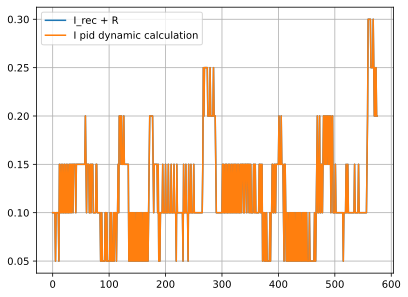

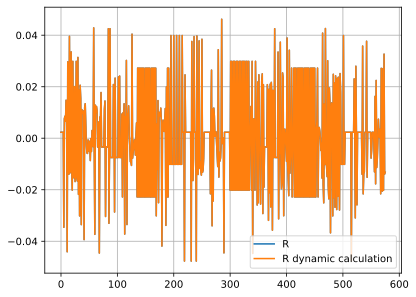

In [5]:
CGM   = (scaler_glucose.denormalize(dataset.CGM.detach())).numpy();              G     = (scaler_glucose.denormalize(dataset.G.detach())).numpy()
                                                                                                                                 
I_sat       = (scaler_insulin.denormalize(dataset.I_sat.detach())).numpy();      I_rec = (scaler_insulin.denormalize(dataset.I_rec.detach())).numpy();       
I_sat_rec   = (scaler_insulin.denormalize(dataset.I_sat_rec.detach())).numpy();  R     = (scaler_insulin.denormalize(dataset.R.detach())).numpy()

M       = (scaler_meal.denormalize(dataset.M.detach())).numpy();                 MH    = (scaler_meal.denormalize(dataset.MH.detach())).numpy();          
MH_rec  = (scaler_meal.denormalize(dataset.MH_rec.detach())).numpy()
H       = (scaler_meal.denormalize(dataset.H.detach())).numpy();                 H_rec = (scaler_meal.denormalize(dataset.H_rec.detach())).numpy();     

# R = I_sat (from .mat) - I_rec (exiting the PID and before saturation and noise)
# if  use_noise = True, R contains the noise and the saturation effect


# ------------------------- PID controller dynamic simulation ---------------------------------------------------
CGM_torch = dataset.CGM
time = dataset.time
loaded_parameters = Parameter(patient)
controller = NonLinearController(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise)
u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller(CGM_torch, time)


u_pid           = scaler_insulin.denormalize(u_pid.detach())
u_pid_rwgn      = scaler_insulin.denormalize(u_pid_rwgn.detach())
u_pid_rwgn_sat  = scaler_insulin.denormalize(u_pid_rwgn_sat.detach())
r               = scaler_insulin.denormalize(r.detach())

plt.figure()
plt.plot(I_rec[:2*1440//ts]+ R[:2*1440//ts], label= 'I_rec + R')
plt.plot(u_pid_rwgn_sat.numpy()[:2*1440//ts], label = 'I pid dynamic calculation');             plt.legend();plt.grid(True); plt.show()

plt.figure()
plt.plot(R[:2*1440//ts], label= 'R')
plt.plot(r.numpy()[:2*1440//ts], label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()


### parallelization batches

c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\code\exp_100\models_SSM.py:613: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  basal = torch.tensor(basal, dtype=torch.float32) # MODIFICATO PER BATCH


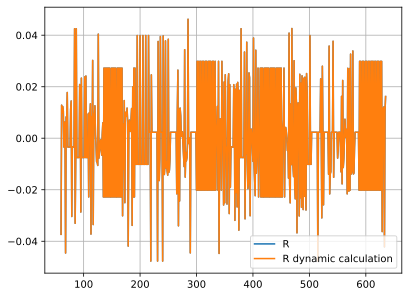

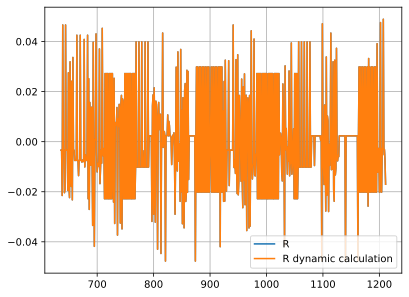

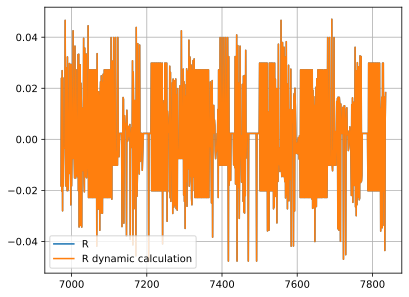

In [6]:
# train start 5 h aafter midnight, every batch 48 h long finishing at 4:55 am


# time definitions
ts_per_hour = 12           # 288 timesteps = 24h → 12 timesteps/hour (5 min each)
hours_per_batch = 48       # 2 days = 48 hours
steps_per_batch = hours_per_batch * ts_per_hour  # 48*12 = 576

start_train = start_valid        #60    [1 element every 5 minutes] I eliminate eqully the first 5 hours from training set

train_dataset = torch.utils.data.Subset(dataset, range(start_train, train_size+start_valid))



# === FUNZIONE: crea blocchi fissi ===
def create_fixed_batches(total_length, chunk_size=576, start_idx=0):
    """
    Divide il dataset in batch temporali fissi (48h).
    Ogni batch è una lista di indici consecutivi.
    L'ultimo batch viene scartato se più corto di chunk_size.
    """
    batches = []
    start = start_idx
    while start + chunk_size <= total_length:
        end = start + chunk_size
        batches.append(list(range(start, end)))
        start = end
    return batches


# === COSTRUISCI I BATCH INDICI ===
train_indices = create_fixed_batches(len(train_dataset), chunk_size=steps_per_batch)

starting_indices = [batch[0] for batch in train_indices]

batch_size=len(starting_indices)

def collate_train_indices(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset[i][0] for i in batch]) # MH # shape: (12, 576, input_dim)
    u1_batch = torch.stack([train_dataset[i][3] for i in batch]) # I_sat
    ur_batch = torch.stack([train_dataset[i][2] for i in batch]) # r
    y_batch  = torch.stack([train_dataset[i][4] for i in batch])
    time_batch = torch.stack([train_dataset[i][5] for i in batch])
    
    return u0_batch, None, ur_batch, u1_batch, y_batch, time_batch



train_loader_p = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices,
    drop_last = True  # opzionale, elimina batch incompleti
)


saturation_error_init, glucose_PID_init, y0_1 = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)

y0_0 = torch.zeros_like(y0_1) # meal ren initialized to 0

controller_p2 = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)

controller_p2.reset(saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)

# === LOOP DI TRAINING ===
for n_batch, (u0_batch, _, _, u1_batch, y_batch, time_batch) in enumerate(train_loader_p):

    u0_batch, u1_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller_p2(CGM = y_batch.squeeze(2), time = time_batch.squeeze(2))
    
r = scaler_insulin.denormalize(r.detach())
for i in range(2):
    plt.figure()
    plt.plot(time_batch[i,:].numpy(), R[time_batch[i,:].squeeze().numpy().astype(int)], label= 'R')
    plt.plot(time_batch[i,:].numpy(), r[i,:].numpy(), label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()
    
    

# === LOOP DI val ===
# !!! reset va lasciato a 0 solo se parto proprio dall'istante zero, con valid in realtà la simulazione era andata già da un po'

saturation_error_init, glucose_PID_init, y0_1 = fun_start_controller(val_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
controller_p2.reset(saturation_error_init=saturation_error_init, glucose_PID_init=glucose_PID_init)
for u0_batch, _, _, u1_batch, y_batch, time_batch in val_loader:
    
    u0_batch, u1_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    u_pid, u_pid_rwgn, u_pid_rwgn_sat, r = controller_p2(CGM = y_batch.squeeze(2), time = time_batch.squeeze(2))
    
r = scaler_insulin.denormalize(r.detach())

plt.figure()
plt.plot(time_batch[0,:].numpy(), R[time_batch[0,:].squeeze().numpy().astype(int)], label= 'R')
plt.plot(time_batch[0,:].numpy(), r[0,:].numpy(), label = 'R dynamic calculation');                             plt.legend();plt.grid(True); plt.show()

### other plots

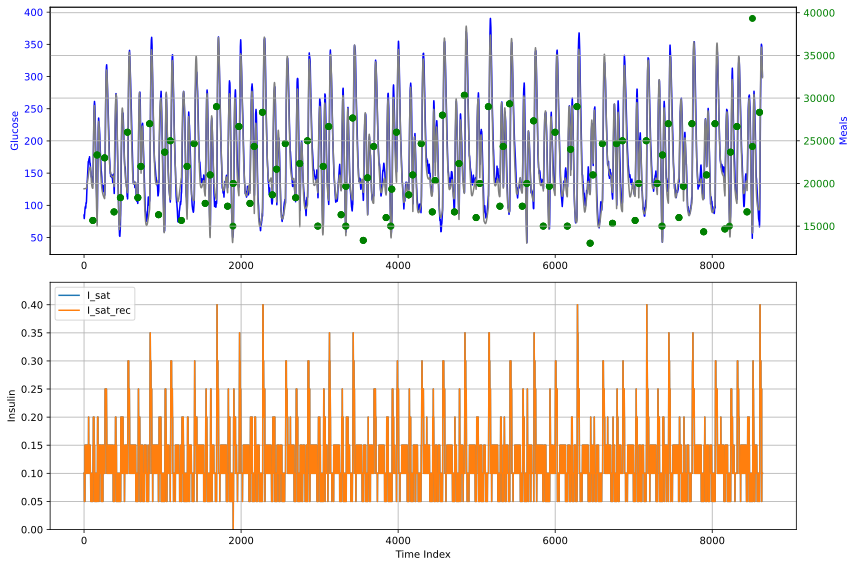

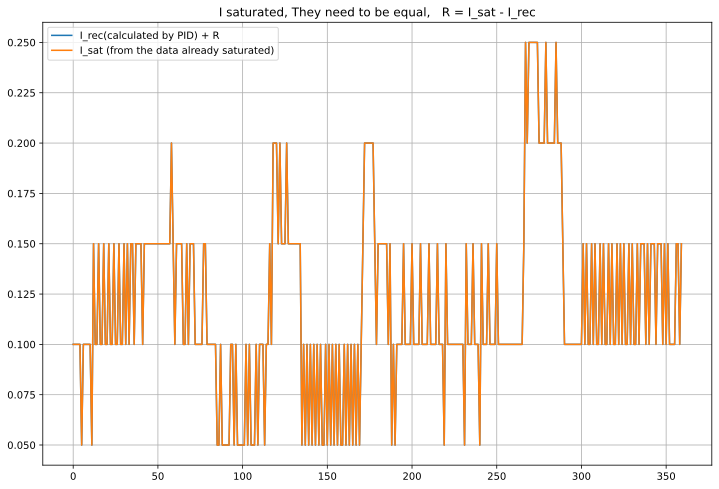

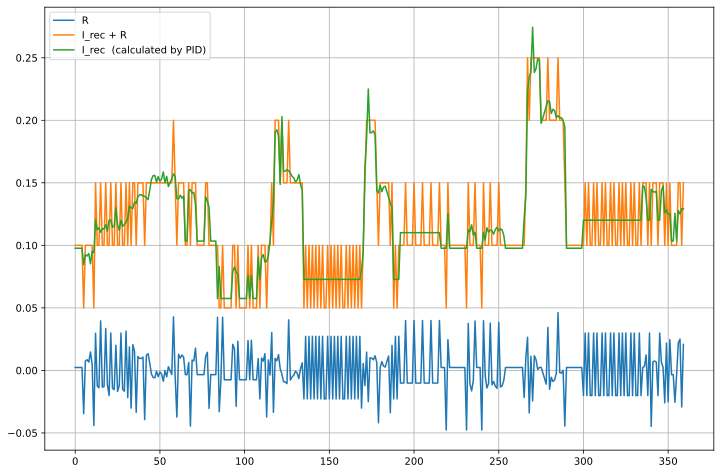

In [7]:
plt.figure(1, figsize=(12, 8))

# Subplot 1
ax1 = plt.subplot(2, 1, 1)
ax1.plot(CGM[:], 'b-', label='Glucose sensor CGM')
ax1.plot(G[:], 'gray', label='Glucose');                                                               ax1.set_ylabel('Glucose', color='b'); ax1.tick_params(axis='y', labelcolor='b'); ax1_right = ax1.twinx()
MHtemp = MH[:].copy()
ax1_right.scatter(np.arange(len(MHtemp))[MHtemp!=0], MHtemp[MHtemp!=0], color='g', label='Meals and hypo');         ax1_right.set_ylabel('Meals', color='b'); ax1_right.tick_params(axis='y', labelcolor='g'); plt.grid(True)

# Subplot 2
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(range(len(I_sat[:])), I_sat[:].flatten(), label='I_sat')
ax2.plot(range(len(I_sat_rec[:])), I_sat_rec[:], label='I_sat_rec');                                      ax2.set_ylim([0, np.max(I_sat_rec) * 1.1]); ax2.legend(); ax2.set_xlabel('Time Index'); ax2.set_ylabel('Insulin')

plt.tight_layout(); plt.grid(True); plt.show()



plt.figure(3, figsize=(12, 8))
plt.plot(I_rec[:1440//4]+ R[:1440//4], label = 'I_rec(calculated by PID) + R')
plt.plot(I_sat[:1440//4], label= 'I_sat (from the data already saturated)')
plt.title('I saturated, They need to be equal,   R = I_sat - I_rec');                   plt.legend();plt.grid(True); plt.show()

plt.figure(4, figsize=(12, 8))
plt.plot(R[:1440//4], label= 'R')
plt.plot(I_rec[:1440//4]+ R[:1440//4], label= 'I_rec + R')
plt.plot(I_rec[:1440//4], label = 'I_rec  (calculated by PID)');                             plt.legend();plt.grid(True); plt.show()


# plt.figure(5)
# plt.plot(H, label='H')
# plt.plot(H_rec-100, label='H_rec')
# plt.title('Hypoglycemia Treatments Comparison');                                                    plt.legend(); plt.show()
#
# plt.figure(6)
# plt.plot(CGM[:1440//4], 'b-', label='Glucose sensor CGM')
# plt.plot(G[:1440//4], 'gray', label='Glucose')
# plt.figure(1, figsize=(12, 8))


# Patient 101

### define dataset 101

In [8]:
dataset_101_I = SimpleLoadData(f'{root}/data/train/30days_101_I_v2/', 101,scaler_insulin, scaler_glucose, scaler_meal)
dataset_101_M = SimpleLoadData(f'{root}/data/train/30days_101_M/', 101,scaler_insulin, scaler_glucose, scaler_meal)

train_dataset_101_I = torch.utils.data.Subset(dataset_101_I, range(start_train, train_size+start_valid))
train_dataset_101_M = torch.utils.data.Subset(dataset_101_M, range(start_train, train_size+start_valid))

val_dataset_101_I   = torch.utils.data.Subset(dataset_101_I, range(train_size+start_valid, train_size+start_valid + val_size))
val_dataset_101_M   = torch.utils.data.Subset(dataset_101_M, range(train_size+start_valid, train_size+start_valid + val_size))
test_dataset_101_I  = torch.utils.data.Subset(dataset_101_I, range(train_size+start_valid + val_size, train_size + val_size + test_size))
test_dataset_101_M  = torch.utils.data.Subset(dataset_101_M, range(train_size+start_valid + val_size, train_size + val_size + test_size))

val_loader_101_I = DataLoader(val_dataset_101_I, batch_size=len(val_dataset_101_I), shuffle=False)
val_loader_101_M = DataLoader(val_dataset_101_M, batch_size=len(val_dataset_101_M), shuffle=False)
test_loader_101_I = DataLoader(test_dataset_101_I, batch_size=len(test_dataset_101_I), shuffle=False)
test_loader_101_M = DataLoader(test_dataset_101_M, batch_size=len(test_dataset_101_M), shuffle=False)


def collate_train_indices_101_I(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset_101_I[i][0] for i in batch]) # MH 
    u1_batch = torch.stack([train_dataset_101_I[i][1] for i in batch]) # I_sat   (no RWGN)
    y_batch = torch.stack([train_dataset_101_I[i][2] for i in batch]) # y
    time_batch = torch.stack([train_dataset_101_I[i][3] for i in batch])

    return u0_batch, u1_batch, y_batch, time_batch

def collate_train_indices_101_M(batch):
    """
    batch: lista di 12 sequenze consecutive (ognuna di lunghezza 576)
    batch_size = len(batch) = 12
    """
    # ogni item del batch corrisponde a un indice di train_indices (576 timesteps)
    u0_batch = torch.stack([train_dataset_101_M[i][0] for i in batch]) # MH 
    u1_batch = torch.stack([train_dataset_101_M[i][1] for i in batch]) # I_sat   (no RWGN)
    y_batch = torch.stack([train_dataset_101_M[i][2] for i in batch]) # y
    time_batch = torch.stack([train_dataset_101_M[i][3] for i in batch])

    return u0_batch, u1_batch, y_batch, time_batch


train_loader_p_101_I = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices_101_I,
    drop_last = True  # opzionale, elimina batch incompleti
)

train_loader_p_101_M = DataLoader(
    train_indices,
    batch_size = batch_size,
    shuffle = False,  # oppure True se vuoi mescolare
    collate_fn = collate_train_indices_101_M,
    drop_last = True  # opzionale, elimina batch incompleti
)



### REN model 101, loss function and optimizer parallel
as strategy 1

In [9]:
#--------------------------3. Define model for sysid---------------------------------------------


device = torch.device(device if torch.cuda.is_available() else "cpu")

y0_1 = fun_start_controller_simple(train_loader_p_101_I, dataset_101_I)
y0_0 = torch.zeros_like(y0_1) # meal ren initialized to 0


# TODO: gamma diverso per i 101

# SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 8, ff='GLU', param='l2n')  #lru   l2n gamma prescritto

SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers=7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)  


# SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU',param='l2n')

SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

SSM_0_101 = SSM_0_101.to(device)
SSM_1_101 = SSM_1_101.to(device)

#create the closed loop with the identified model
# closed_loop_G = ClosedLoopSystem(REN_G, controller)

#--------------------------4. Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()


### Train valid and test of 101 

#### 101 I

In [ ]:

optimizer = torch.optim.Adam( list(SSM_1_101.parameters()),   lr=learning_rate)
optimizer.zero_grad()

importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss

#--------------------------5. Training---------------------------------------------------------------------

torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")

SSM_1_101.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs_101):
    # ---------------- TRAINING ---------------- #
    SSM_1_101.train()
    loss_epoch = 0.0  # Accumulate training loss
    loss_I_epoch = 0.0  # Accumulate training loss I

    for _, u1_batch, y_batch, time_batch in train_loader_p_101_I: # MH, I_rec , CGM, time        

        u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
        u1_batch, y_batch, time_batch = u1_batch.to(device), y_batch.to(device), time_batch.to(device)
        
        optimizer.zero_grad()
        

        # y_init_per_batch      torch.zeros_like(y_batch[:,:1])    y_batch[:,:1]
        y1_hat_train = SSM_1_101(u1_batch) # forward
        y_hat_train = -y1_hat_train[0]
        # with monotonicity we have forced a positive response from the insulin REN (REN_1) 
        # but from real-world knowledge it is a negative relation

        loss_batch_train = MSE(y_hat_train, y_batch)
        
        loss_I_train = torch.tensor([0.0])

        total_loss_train = loss_batch_train + loss_I_train

        total_loss_train.backward()
        optimizer.step()
        loss_epoch += total_loss_train.item()
        loss_I_epoch += loss_I_train.item()
        
    loss_epoch /= len(train_loader_p)
    loss_I_epoch /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_1_101.eval()
    loss_val_epoch = 0.0
    loss_I_val_epoch = 0.0

    with torch.no_grad():
        for _, u1_batch, y_batch, time_batch in val_loader_101_I: # MH, I_rec (PID), CGM, time
            
            u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
            u1_batch, y_batch, time_batch = u1_batch.to(device), y_batch.to(device), time_batch.to(device)
            

            y1_hat_val = SSM_1_101(u1_batch)# select the correct U
            y_hat_val = -y1_hat_val[0]
            
            loss_batch_val = MSE(y_hat_val, y_batch)
            loss_I_val = torch.tensor([0.0])
        
            total_loss_val = loss_batch_val + loss_I_val
            loss_I_val_epoch += loss_I_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        
        candidate_SSM_1_101 = SSM_1_101

    loss_val_epoch /= len(val_loader)
    loss_I_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} \t||\t"
              f"Train L: {loss_epoch:.6f}   \t||\t Train L_I: {loss_I_epoch:.6f} \t||\t"
              f"Val L: {loss_val_epoch:.6f} \t||\t Val L_I: {loss_I_val_epoch:.6f}")


patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/for_paz_{patient:03d}"
if redo_save_101_I:
    # model on CPU before saving
    candidate_SSM_1_101_cpu = candidate_SSM_1_101.to('cpu')

    # Save the best model
    # 1. Create models directory
    MODEL_PATH = Path(patient_model_folder_101_I)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_1_101_state_dict': candidate_SSM_1_101_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder_101_I) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})

#### test 101 I

epoca migliore: 0


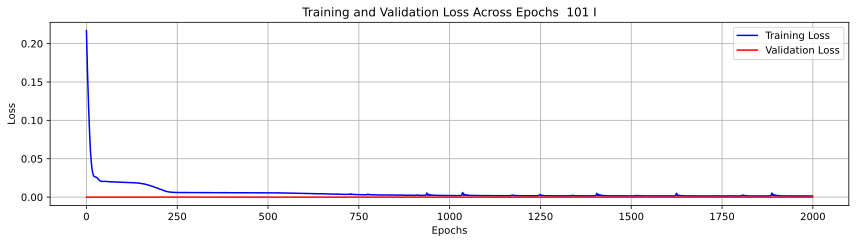

c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\non_lin_sys_id\lib\site-packages\neural_ssm\ssm\lru.py:1029: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  block = torch.tensor(


Loss train: 0.001942410133779049


c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\code\exp_4\./../..\utils_SSM.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


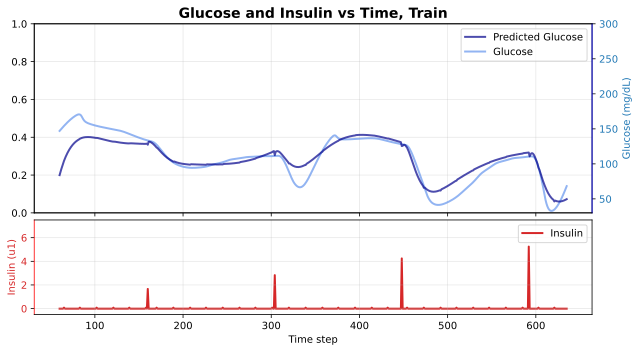

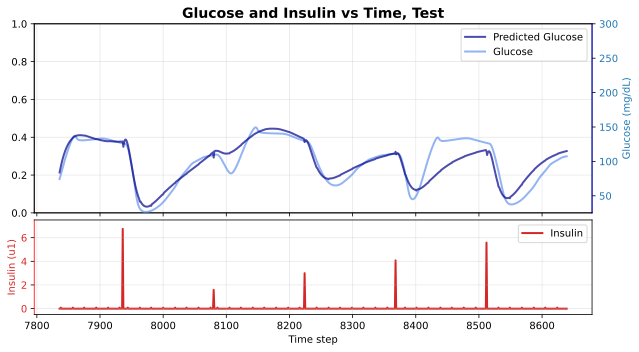

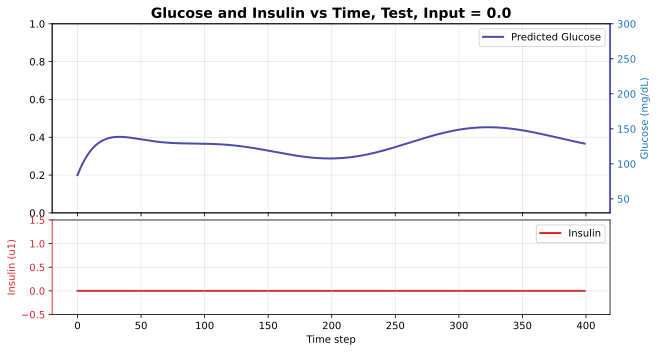

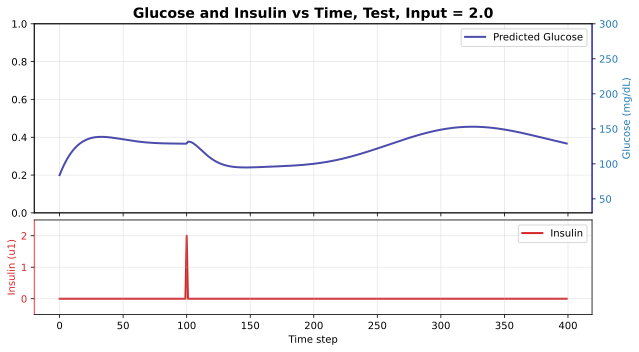

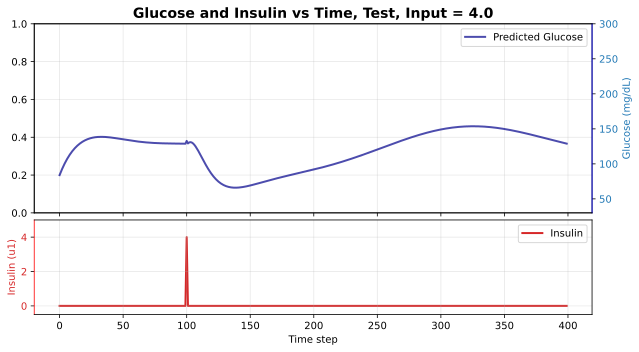

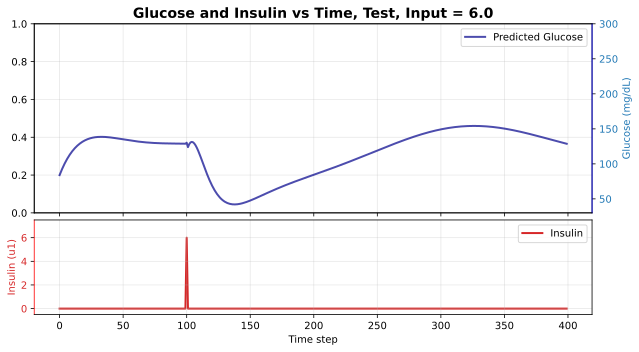

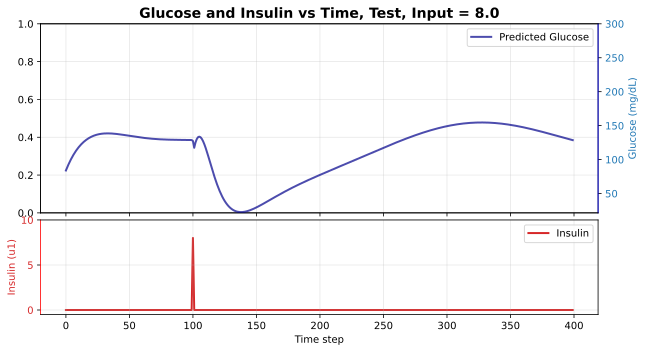

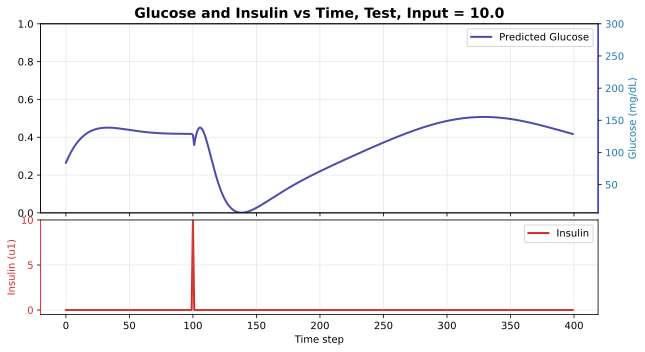

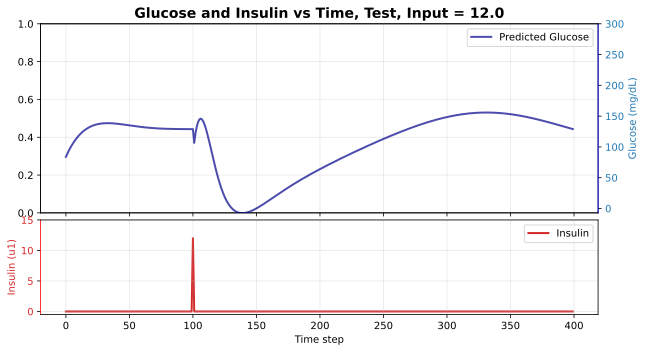

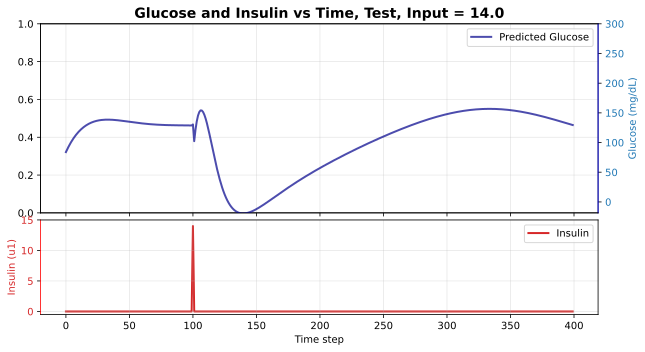

In [ ]:

# --------------Plot identification results_v3_v3_v3 for G-----------------

patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_I)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best = int(params["epoch_when_model_saved"][0].item())

print(f"epoca migliore: {epoch_best}")



# ----------------------------------

#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs_101), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs_101), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs  101 I')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------

SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n',
                    d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)


checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1_101.load_state_dict(checkpoint["SSM_1_101_state_dict"])

#################################################################

for _, u1_batch, y_batch, time_batch in train_loader_p_101_I:

    u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    
    y1_hat = SSM_1_101(u1_batch)
    y_hat = -y1_hat[0]
    
    loss_train = MSE(y_hat, y_batch)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    
    break # just first batch

print(f"Loss train: {loss_train}")


plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Insulin vs Time, Train')



#####################################################################################



for _, u1_batch, y_batch, time_batch in test_loader_101_I:

    u1_batch, y_batch, time_batch = ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    y1_hat = SSM_1_101(u1_batch)
    y_hat = -y1_hat[0]

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    

plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(), glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Insulin vs Time, Test')


# prima non era propriamente corretto, controllare ora se propriamente corretto: il modello è il closed loop non il dual ren
# in questo modo vedo se effettivamente la condizione di monotonicità è rispettata o cisono degli errori in giro
# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8, 10, 12, 14]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0_101.eval();                          SSM_1_101.eval()


    y1_hat, _ = SSM_1_101(fake_insulin)
    y_hat =  - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]

    plot_glucose_insulin(time[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")


#### 101 M

In [ ]:

optimizer = torch.optim.Adam( list(SSM_0_101.parameters()),   lr=learning_rate)
optimizer.zero_grad()

#--------------------------5. Training---------------------------------------------------------------------

torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")

SSM_0_101.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs_101):
    # ---------------- TRAINING ---------------- #
    SSM_0_101.train()
    loss_epoch = 0.0  # Accumulate training loss

    
    for u0_batch, _, y_batch, time_batch in train_loader_p_101_M: # MH, I_rec (PID), CGM, time

        

        u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
        u0_batch, y_batch, time_batch = u0_batch.to(device), y_batch.to(device), time_batch.to(device)
        
        optimizer.zero_grad()
        

        # y_init_per_batch      torch.zeros_like(y_batch[:,:1])    y_batch[:,:1]
        y0_hat_train = SSM_0_101(u0_batch) # forward
        y_hat_train = y0_hat_train[0]
        # with monotonicity we have forced a positive response from the insulin REN (REN_1) 
        # but from real-world knowledge it is a negative relation

        loss_batch = MSE(y_hat_train, y_batch)

        loss_batch.backward()
        optimizer.step()
        loss_epoch += loss_batch.item()

    loss_epoch /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_0_101.eval()
    loss_val_epoch = 0.0

    with torch.no_grad():
        for u0_batch, _, y_batch, time_batch in val_loader_101_M: # MH, I_rec (PID), CGM, time

            u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
            u0_batch, y_batch, time_batch = u0_batch.to(device), y_batch.to(device), time_batch.to(device)
            

            y0_hat_val = SSM_0_101(u0_batch)# select the correct U
            y_hat_val = y0_hat_val[0]
            
            loss_batch_val = MSE(y_hat_val, y_batch)

            loss_val_epoch += loss_batch_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        
        candidate_SSM_0_101 = SSM_0_101

    loss_val_epoch /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 100 == 0:
        print(f"Epoch: {epoch + 1} \t||\t Training Loss: {loss_epoch:.6f} \t||\t Validation Loss: {loss_val_epoch:.6f}")


patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/for_paz_{patient:03d}"
if redo_save_101_M:
    # model on CPU before saving
    candidate_SSM_0_101_cpu = candidate_SSM_0_101.to('cpu')

    # Save the best model
    # 1. Create models directory
    MODEL_PATH = Path(patient_model_folder_101_M)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_0_101_state_dict': candidate_SSM_0_101_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder_101_M) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})

#### test 101 M

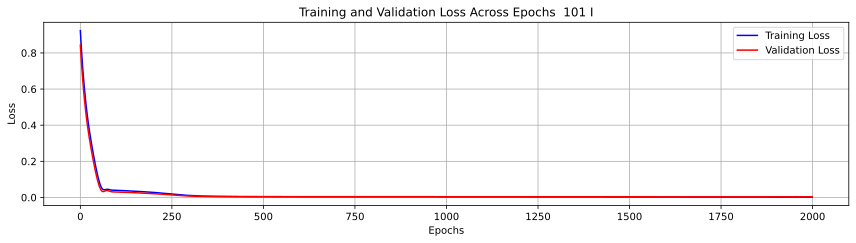

Loss train: 0.0019077137112617493


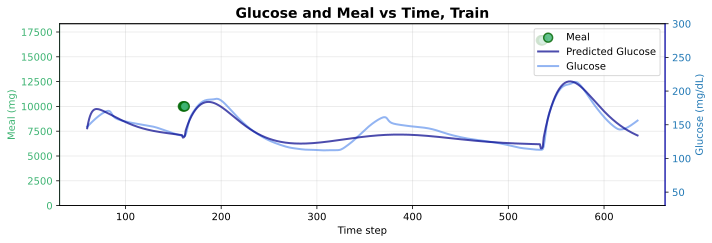

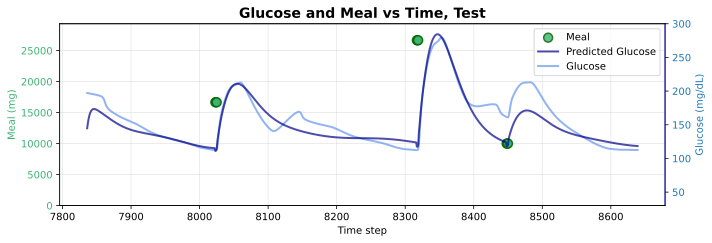

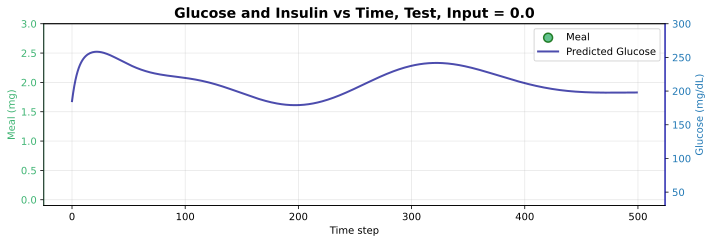

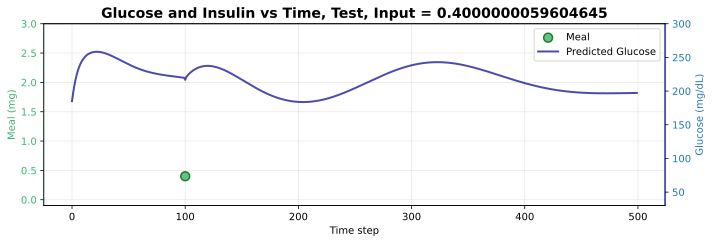

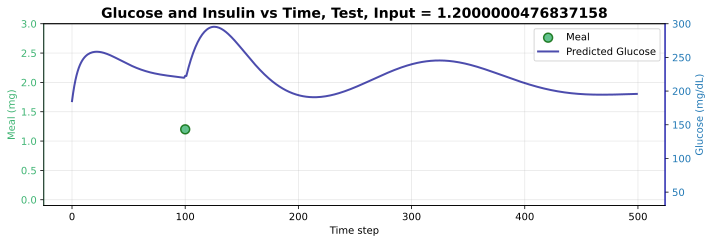

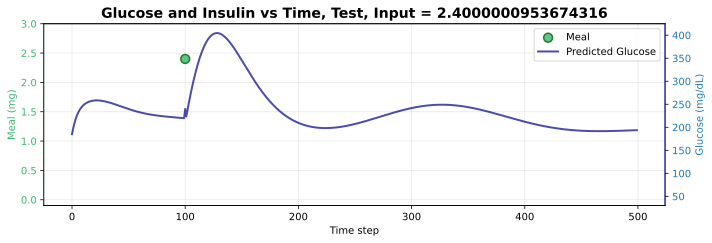

In [11]:

# --------------Plot identification results for G-----------------

patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_M)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]

epoch_best = int(params["epoch_when_model_saved"][0].item())
# ----------------------------------


#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs_101), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs_101), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs  101 I')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()



SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, ff='GLU', param='l2n',
                    d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  



checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])

#################################################################

for u0_batch, _, y_batch, time_batch in train_loader_p_101_M:

    u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)
    

    y0_hat = SSM_0_101(u0_batch)
    y_hat = y0_hat[0]
    
    loss_train = MSE(y_hat, y_batch)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    u0_batch_np = scaler_meal.denormalize(u0_batch.detach().cpu()).numpy()
    
    break # just first batch

print(f"Loss train: {loss_train}")
plot_glucose_insulin(time_batch[0,:,0].numpy(), meal=u0_batch_np[0,:,0], glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Meal vs Time, Train')



#####################################################################################


for u0_batch, _, y_batch, time_batch in test_loader_101_M:

    u0_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(y_batch), ensure_3d(time_batch)

    y0_hat = SSM_0_101(u0_batch)
    y_hat = y0_hat[0]

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    u0_batch_np = scaler_meal.denormalize(u0_batch.detach().cpu()).numpy()


plot_glucose_insulin(time_batch[0,:,0].numpy(), meal=u0_batch_np[0,:,0], glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_np[0,:,0], title='Glucose and Meal vs Time, Test')


# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:

    fake_meal = np.zeros(500)
    fake_meal[100] = sample 
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];    fake_insulin = fake_insulin[None,:, None]
    SSM_0_101.eval();                           SSM_1_101.eval()

    # fake_meal = scaler_glucose.normalize(fake_meal)

    y0_hat, _ = SSM_0_101(fake_meal)
    y1_hat, _ = SSM_1_101(fake_insulin)
    y_hat = y0_hat - y1_hat
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()


    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    # fake_meal = scaler_glucose.denormalize(fake_meal)

    plot_glucose_insulin(time[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




# Strategy 1 
System identification of G

## test 101 with data from patient i

c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\non_lin_sys_id\lib\site-packages\neural_ssm\ssm\lru.py:1029: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  block = torch.tensor(
c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\code\exp_4\./../..\utils_SSM.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


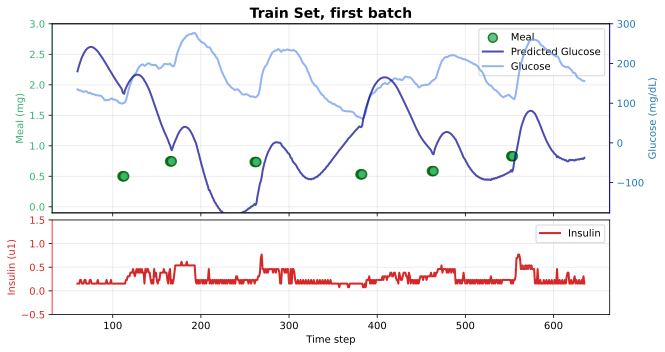

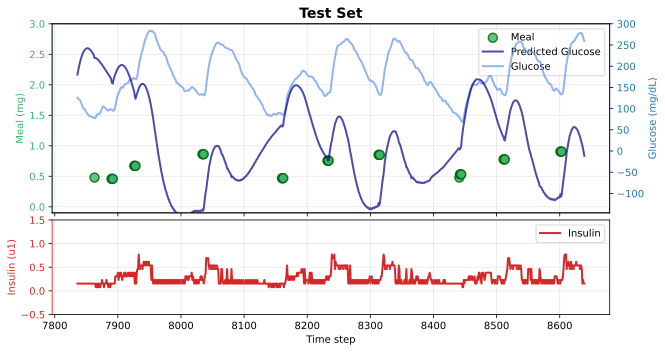

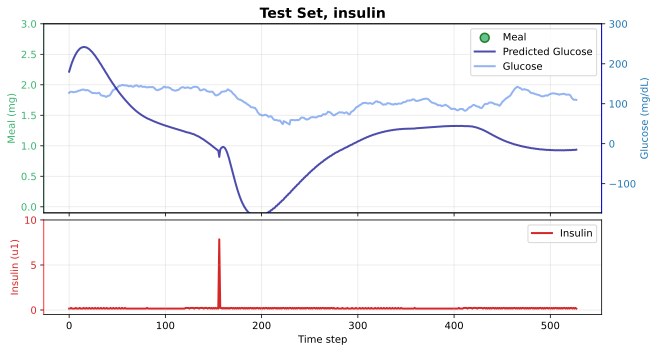

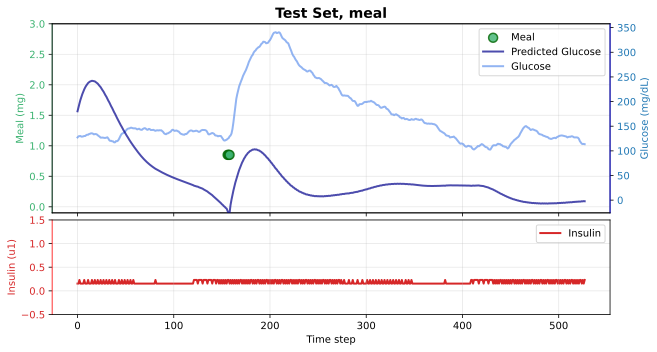

In [10]:

# --------------Plot identification results for G-----------------

patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_I)

SSM_1_101 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n',
                    d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)


checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1_101.load_state_dict(checkpoint["SSM_1_101_state_dict"])

SSM_1 = copy.deepcopy(SSM_1_101.to(device))


# --------------Plot identification results for G-----------------

patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_M)

SSM_0_101 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, ff='GLU', param='l2n',
                    d_state=8, n_layers=7, max_phase_b=0.04,  d_hidden=12, dim_amp=3)  

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])

SSM_0 = copy.deepcopy(SSM_0_101.to(device))
SSM_1.eval()


# -------------------------------------------------------------

for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")





for u0_batch, _, _, u1_batch, y_batch, time in test_loader:   # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    


plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set")



# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader( test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")


# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)

    
for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    y_hat = y0_hat - y1_hat

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal")
    


## define models

In [11]:
#--------------------------3. Define model for sysid---------------------------------------------

patient_model_folder_101_I = f"{root}/models/SSM/101_I/{folder_model_101}/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_I)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_1_101.load_state_dict(checkpoint["SSM_1_101_state_dict"])

patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_M)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])


device = torch.device(device if torch.cuda.is_available() else "cpu")

SSM_0 = copy.deepcopy(SSM_0_101.to(device))
SSM_1 = copy.deepcopy(SSM_1_101.to(device))

#--------------------------4. Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()

optimizer = torch.optim.Adam( list(SSM_0.parameters()) + list(SSM_1.parameters()),   lr=learning_rate)
optimizer.zero_grad()

## Train

In [ ]:
#--------------------------5. Training---------------------------------------------------------------------

importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss


torch.set_default_device(device)      # default tensor device
torch.set_default_dtype(torch.float32)  # default tensor dtype
print(f"[INFO] Training on device: {device}")




SSM_0.to(device); SSM_1.to(device)
train_losses = []
val_losses = []  # Store validation losses across epochs
for epoch in range(epochs_s1):
    # ---------------- TRAINING ---------------- #
    SSM_0.train(); SSM_1.train()
    loss_epoch, loss_epoch_I = 0.0, 0.0  # Accumulate training loss
    
    for u0_batch, _, _, u1_batch, y_batch, time_batch in train_loader_p: # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time



        u0_batch, u1_batch, y_batch, time_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time_batch)
        # batch_size, time_horizon, input_dim
        u0_batch, u1_batch, y_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()

        y0_hat_train, _ = SSM_0(u0_batch) # forward
        y1_hat_train, _ = SSM_1(u1_batch) # forward
        
        if use_low_pass_I:
            y_hat_train = y0_hat_train - l_filter(y1_hat_train) 
        else:
            y_hat_train = y0_hat_train - y1_hat_train 

        loss_batch = MSE(y_hat_train, y_batch)
        
        coeff_monotonic = 1 if use_monotonic_gain_loss else 0
            
        loss_batch_I = coeff_monotonic * monotonic_gain_loss(-y1_hat_train, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                                        evaluate = 'insulin', 
                                                        cumulative_window = cumulative_window, 
                                                        horizon=horizon, 
                                                        aggressive_coeff=1, 
                                                        CR = loaded_parameters.Patient_par.CR,
                                                        CF = loaded_parameters.Patient_par.CF,
                                                        type_preprocess_insulin = type_preprocess_insulin, 
                                                        loaded_parameters=loaded_parameters)
        
        # y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
        # y_hat_train_np = scaler_glucose.denormalize(y_hat_train.detach().cpu()).numpy()
        # y0_hat_train_np = scaler_glucose.denormalize(y0_hat_train.detach().cpu()).numpy()
        # y1_hat_train_np = scaler_glucose.denormalize(-y1_hat_train.detach().cpu()).numpy()

        # plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), meal = u0_batch[0,:,0].numpy(), glucose=y_batch_np[0,:,0], predicted_glucose=y_hat_train_np[0,:,0], title='y_hat_tot')
        
        # plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), meal = u0_batch[0,:,0].numpy(), glucose=y0_hat_train_np[0,:,0], predicted_glucose=y_hat_train_np[0,:,0], title='y_hat_meal')
        
        # plot_glucose_insulin(time_batch[0,:,0].numpy(), insulin = u1_batch[0,:,0].numpy(), meal = u0_batch[0,:,0].numpy(), glucose=y1_hat_train_np[0,:,0], predicted_glucose=y_hat_train_np[0,:,0], title='y_hat_insulin')


        total_loss_batch = loss_batch + loss_batch_I
        
        
        
        total_loss_batch.backward()
        optimizer.step()
        loss_epoch += total_loss_batch.item()
        loss_epoch_I += loss_batch_I.item()

    loss_epoch /= len(train_loader_p)
    loss_epoch_I /= len(train_loader_p)
    
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    SSM_0.eval(); SSM_1.eval()
    loss_val_epoch, loss_val_epoch_I = 0.0, 0.0  # Accumulate training loss

    with torch.no_grad():
        for u0_batch, _, _, u1_batch, y_batch, _ in val_loader: # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

            u0_batch, u1_batch, y_batch= ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch)
            u0_batch, u1_batch, y_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device)

            y0_hat_val, _ = SSM_0(u0_batch)
            y1_hat_val, _ = SSM_1(u1_batch)# select the correct U
            
            if use_low_pass_I:
                y_hat_val = y0_hat_val - l_filter(y1_hat_val) 
            else:
                y_hat_val = y1_hat_val - y1_hat_val 
            
            loss_batch_val = MSE(y_hat_val, y_batch)


            coeff_monotonic = 1 if use_monotonic_gain_loss else 0

            loss_batch_I_val = coeff_monotonic *monotonic_gain_loss(-y1_hat_val, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                                        evaluate = 'insulin', 
                                                        cumulative_window = cumulative_window, 
                                                        horizon=horizon, 
                                                        aggressive_coeff=1, 
                                                        CR = loaded_parameters.Patient_par.CR,
                                                        CF = loaded_parameters.Patient_par.CF,
                                                        type_preprocess_insulin = type_preprocess_insulin, 
                                                        loaded_parameters=loaded_parameters)

            total_loss_val = loss_batch_val + loss_batch_I_val
            loss_val_epoch += total_loss_val.item()
            loss_val_epoch_I += loss_batch_I_val.item()

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        candidate_SSM_0 = SSM_0
        candidate_SSM_1 = SSM_1

    loss_val_epoch /= len(val_loader)
    loss_val_epoch_I /= len(val_loader)
    val_losses.append(loss_val_epoch)  # Store validation loss for plotting

    if epoch % 10 == 0:
        print(f"Train Loss || Epoch: {epoch} \t||\t total: {loss_epoch:.6f} \t||\t I: {loss_epoch_I:.6f} || ")
        print(f"Val   Loss || Epoch: {epoch} \t||\t total: {loss_val_epoch:.6f} \t||\t I: {loss_val_epoch_I:.6f} || ")

if redo_save:
    # model on CPU before saving
    candidate_SSM_0_cpu = candidate_SSM_0.to('cpu')
    candidate_SSM_1_cpu = candidate_SSM_1.to('cpu')

    # Save the best model
    # 1. Create models directory
    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 
    
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    # 2. save model state dict
    torch.save({
    'SSM_0_state_dict': candidate_SSM_0_cpu.state_dict(),
    'SSM_1_state_dict': candidate_SSM_1_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')


    # save .mat
    np_x0 = x0.detach().cpu().numpy(); np_input_dim = np.array(input_dim); np_output_dim = np.array(output_dim); np_dim_internal =np.array(dim_internal); np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy(); np_gamma = gamma.cpu().numpy()
    
    # 4. Create params directory
    params_folder = Path(patient_model_folder) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})


## smal test to debug train

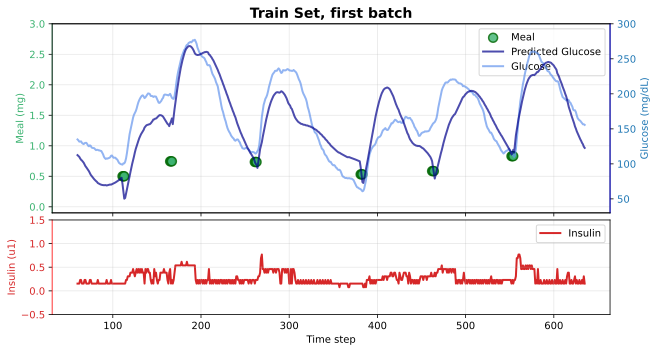

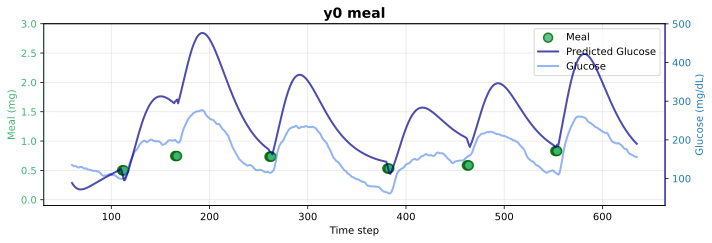

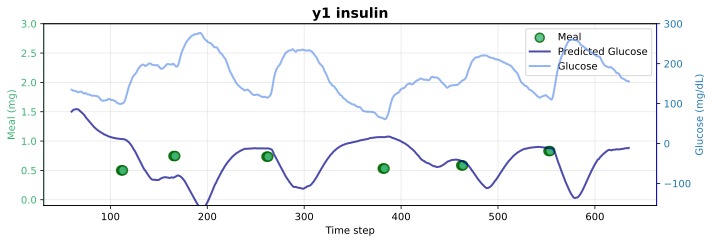

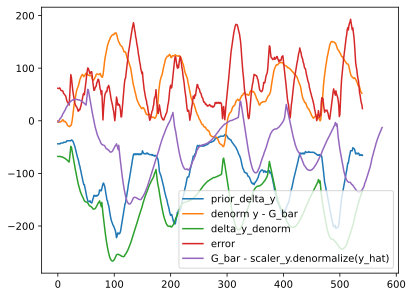

In [ ]:
importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss

# --------------Plot identification result s for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 

MODEL_PATH = Path(patient_model_folder)



# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")

SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])

SSM_0.eval()
SSM_1.eval()

for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y_hat = y0_hat - l_filter(y1_hat) 
    else:
        y_hat = y0_hat - y1_hat 
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality =  monotonic_gain_loss(-y_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                                evaluate = 'insulin', 
                                                cumulative_window = cumulative_window, 
                                                horizon=horizon, 
                                                aggressive_coeff=1, 
                                                CR = loaded_parameters.Patient_par.CR,
                                                CF = loaded_parameters.Patient_par.CF,
                                                G_bar=torch.tensor([110]),
                                                return_debug = True,
                                                type_preprocess_insulin = type_preprocess_insulin, 
                                                loaded_parameters=loaded_parameters)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    y0_hat_train_np = scaler_glucose.denormalize(y0_hat.detach().cpu()).numpy()
    y1_hat_train_np = scaler_glucose.denormalize(-y1_hat.detach().cpu()).numpy()
    
    time_plot = time.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y0_hat_train_np[0,:,0], title=f"y0 meal")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y1_hat_train_np[0,:,0], title=f"y1 insulin")


plt.figure(); G_bar = torch.tensor([110]);     cumulative_window = int(cumulative_window); horizon = int(horizon)
a = prior_delta_y[0,:,0].detach().cpu().numpy()
plt.plot(a, label = "prior_delta_y")
plt.plot( scaler_glucose.denormalize(y_batch[0,cumulative_window:-horizon,0]).detach().cpu().numpy() - G_bar.numpy(), label = "denorm y - G_bar")
plt.plot( delta_y_denorm[0,:,0].detach().cpu().numpy(), label = "delta_y_denorm")
plt.plot(500*torch.abs(error[0,:,0]).detach().numpy(), label = "error")
plt.plot(G_bar - scaler_glucose.denormalize(y_hat[0,:,0]).detach().cpu().numpy(), label = "G_bar - scaler_y.denormalize(y_hat)")
plt.legend()
plt.show()

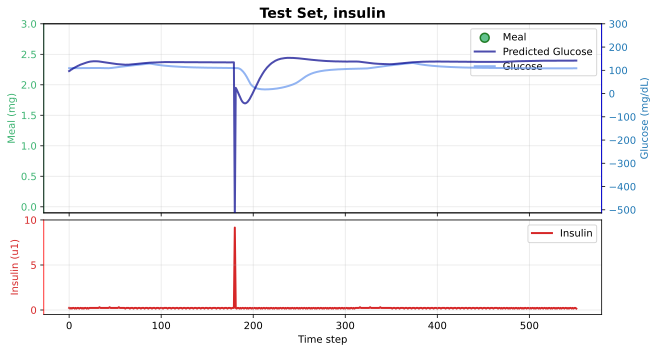

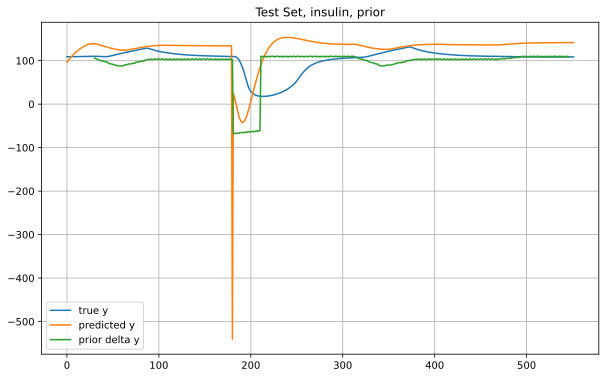

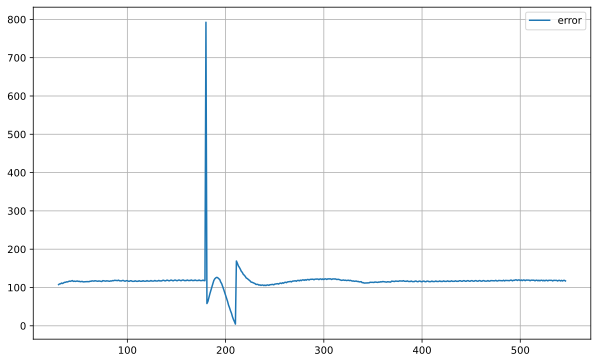

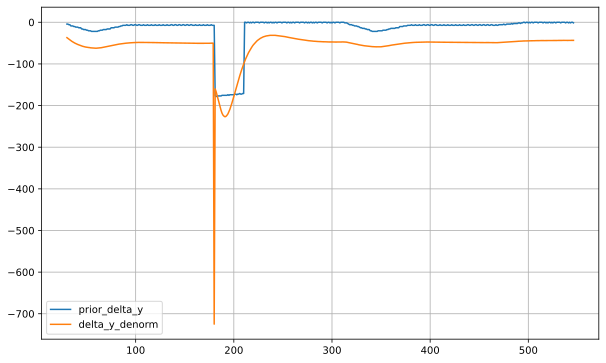

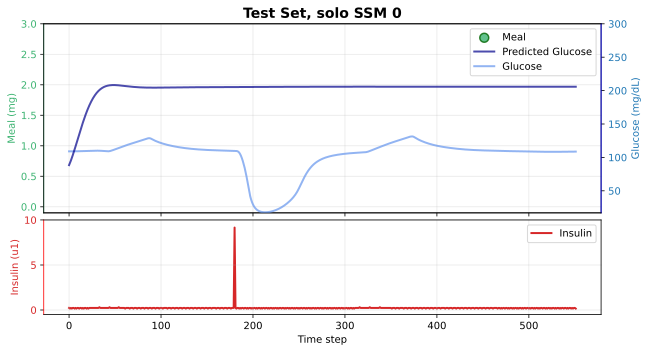

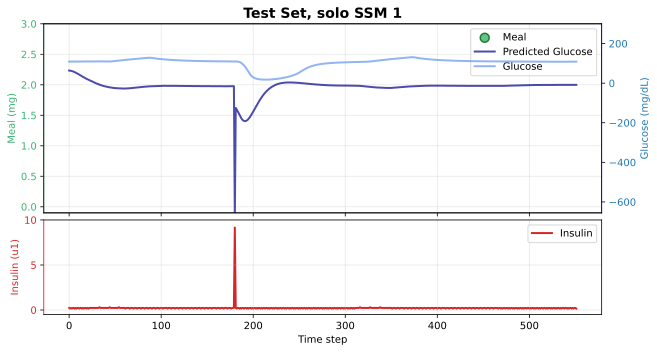

ciao


In [ ]:
# patient = 10

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 
MODEL_PATH = Path(patient_model_folder)

# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])
SSM_0.eval(); SSM_1.eval()
cumulative_window = int(cumulative_window); horizon = int(horizon)  

# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])
SSM_0.eval()
SSM_1.eval()

# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_insulin_30g_13h/'
loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['G']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader( test_dataset_new, batch_size=1, shuffle=False)

for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y_hat = y0_hat - l_filter(y1_hat) 
    else:
        y_hat = y0_hat - y1_hat 
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality = 1 * monotonic_gain_loss(-y1_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                            evaluate = 'insulin', 
                                            cumulative_window = cumulative_window, 
                                            horizon=horizon, 
                                            aggressive_coeff=1, 
                                            CR = loaded_parameters.Patient_par.CR,
                                            CF = loaded_parameters.Patient_par.CF,
                                            G_bar=torch.tensor([110]),
                                            return_debug = True,
                                            type_preprocess_insulin = type_preprocess_insulin, 
                                            loaded_parameters=loaded_parameters)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    y0_hat_np = scaler_glucose.denormalize(y0_hat.detach().cpu()).numpy()
    y1_hat_np = scaler_glucose.denormalize(-y1_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u1_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_min_value, y_min_index = torch.min(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_min_index = y_min_index.item() + u_max_index.item()
    # guarda min da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_when_u_max) - scaler_glucose.denormalize(y_min_value) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_min_index - u_max_index.item()) * 5  # in minuti
    
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")

plt.figure(figsize=(10,6))
plt.plot(time_plot[0,:,0].numpy(), y_batch_np[0,:,0], label='true y')
plt.plot(time_plot[0,:,0].numpy(), y_hat_np[0,:,0], label='predicted y')
plt.plot(time_plot[0, cumulative_window:-horizon+1,0].numpy(), prior_delta_y[0,:,0].detach().cpu().numpy()+110, label='prior delta y')
plt.title("Test Set, insulin, prior")
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(10,6))
plt.plot(time_plot[0, cumulative_window:-horizon+1,0].numpy(),scaler_glucose.denormalize(error[0,:,0]).detach().numpy(), label = "error")
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(10,6))
plt.plot(time_plot[0, cumulative_window:-horizon+1,0].numpy(),prior_delta_y[0,:,0].detach().numpy(), label = "prior_delta_y")
plt.plot(time_plot[0, cumulative_window:-horizon+1,0].numpy(),delta_y_denorm[0,:,0].detach().numpy()+75, label = "delta_y_denorm") # 
plt.legend(); plt.grid(); plt.show()

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y0_hat_np[0,:,0], title=f"Test Set, solo SSM 0")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y1_hat_np[0,:,0], title=f"Test Set, solo SSM 1")



print(f"ciao")



# -------------------------------------------------------------


## test

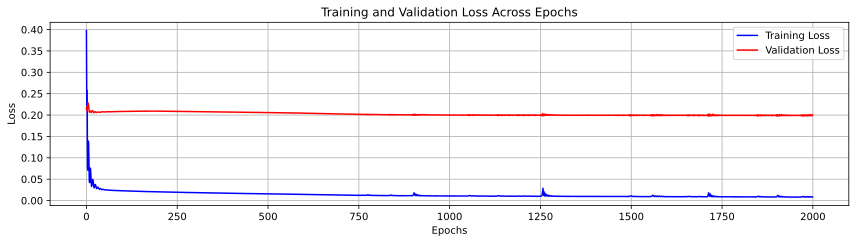

c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified\code\exp_100\./../..\utils_SSM_100.py:286: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


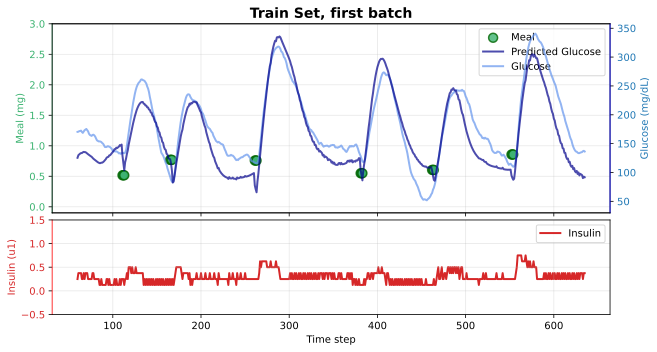

Modificato FIT_SSM_34 (riga 2): 65.97526371479034

✓ File c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified/results_v3.xlsx aggiornato con successo


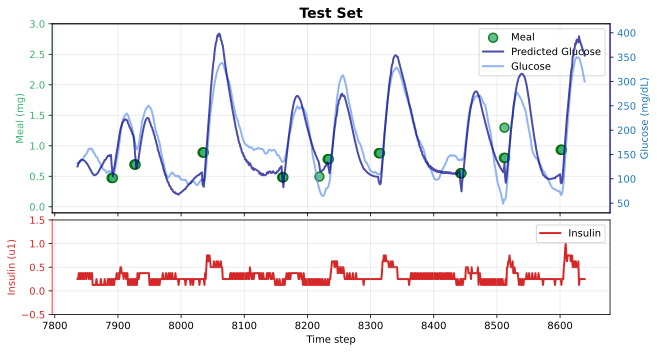

Modificato FIT_SSM_34 (riga 12): 60.26768684387207

✓ File c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified/results_v3.xlsx aggiornato con successo


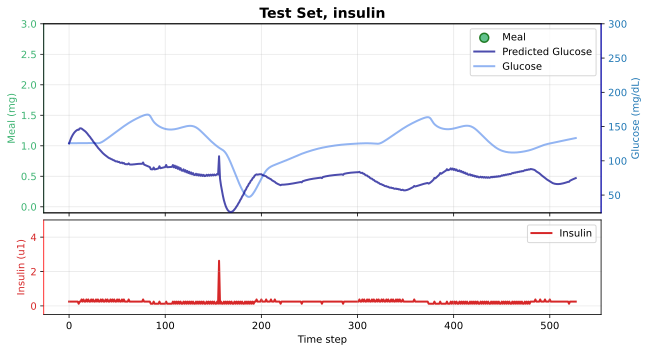

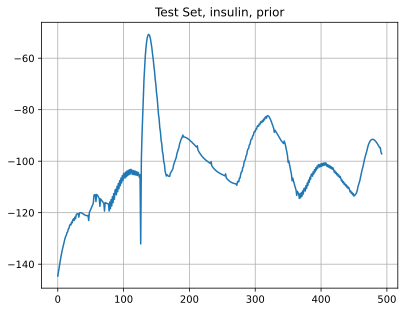

Modificato delta_G_SSM_34 (riga 22): 54.54808044433594
Modificato delta_t_SSM_34 (riga 22): 45

✓ File c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified/results_v3.xlsx aggiornato con successo
Modificato p_i_34 (riga 22): -32.64851379394531

✓ File c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified/results_v3_peacks.xlsx aggiornato con successo


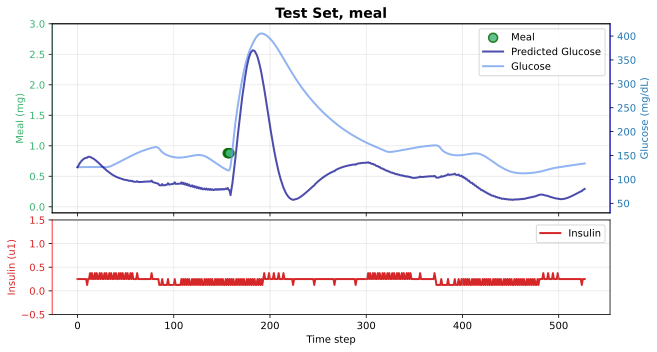

Modificato delta_G_SSM_34 (riga 32): 290.4276428222656
Modificato delta_t_SSM_34 (riga 32): 115

✓ File c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified/results_v3.xlsx aggiornato con successo
Modificato p_m_34 (riga 32): -10.315193176269531

✓ File c:\Users\pmong\OneDrive - Università di Pavia\EPFL\Nonlinear_system_identification_modified/results_v3_peacks.xlsx aggiornato con successo


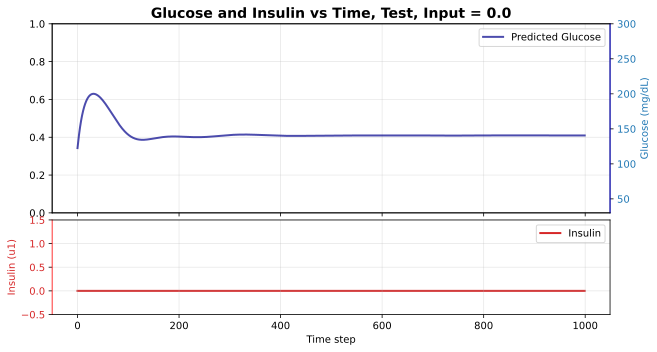

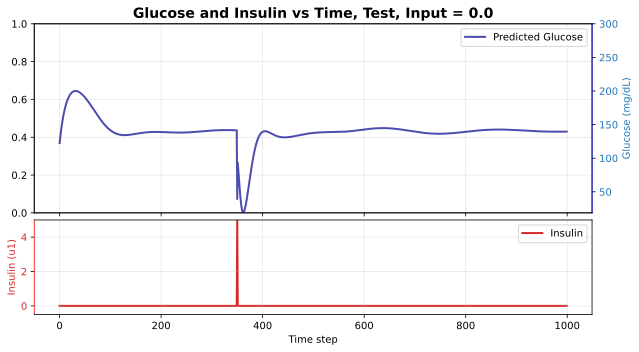

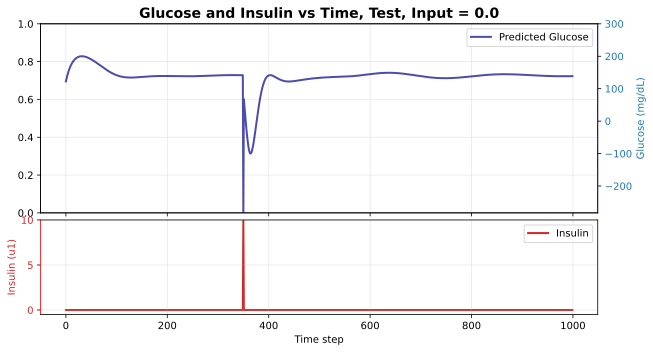

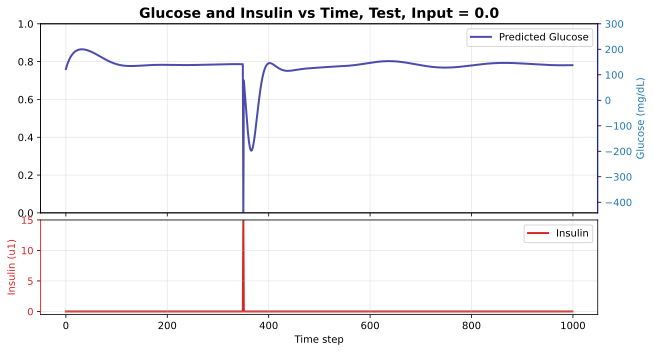

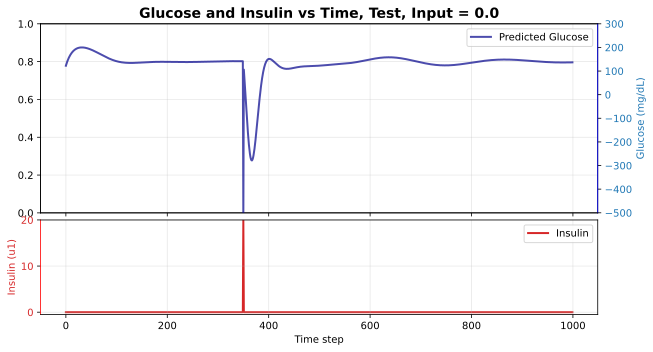

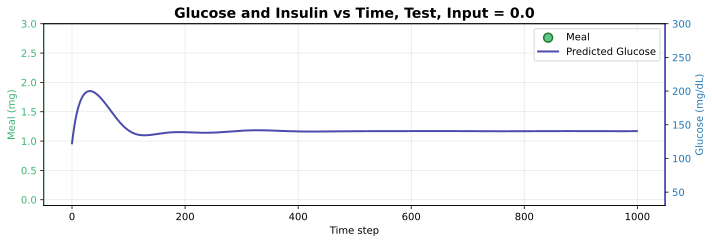

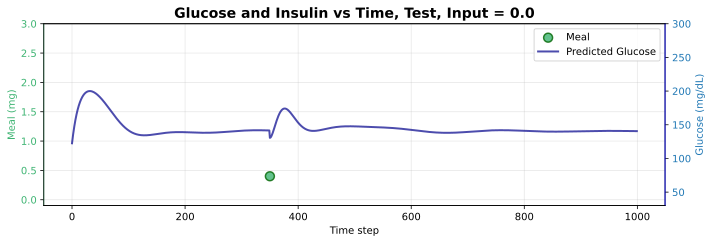

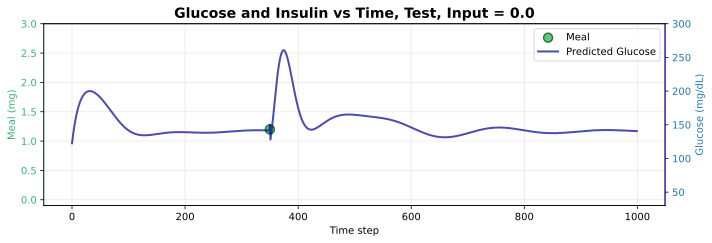

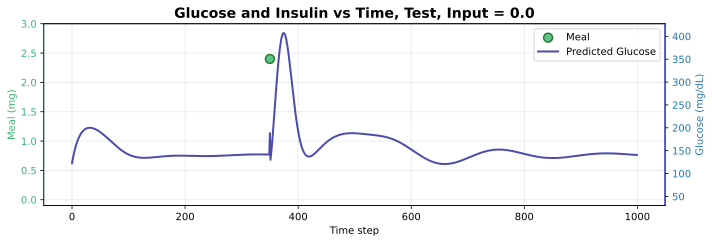

In [11]:

# --------------Plot identification result s for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_1" 
MODEL_PATH = Path(patient_model_folder)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0].item())


# ----------------------------------

# epochs = epochs

#Training and Validation Loss Across Epochs
plt.figure(figsize=(12, 3.5))
plt.plot(range(epochs_s1), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs_s1), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8,  n_layers = 7, ff='GLU',param='l2n', d_state=8, max_phase_b=0.04,  d_hidden=12, dim_amp=3)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")

SSM_0.load_state_dict(checkpoint["SSM_0_state_dict"])
SSM_1.load_state_dict(checkpoint["SSM_1_state_dict"])

SSM_0.eval()
SSM_1.eval()

scenarios = {'train_batch_1': 0, 'test_similar_to_train': 1, 'insulin_impulse': 2, 'meal_impulse': 3}

# --------------Plot identification results for G-----------------

tot_FIT = []

for u0_batch, _, _, u1_batch, y_batch, time in train_loader_p:

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y_hat = y0_hat - l_filter(y1_hat) 
    else:
        y_hat = y0_hat - y1_hat 

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    for i in range(y_batch_np.shape[0]):  # itera su 12 batch
        fit_val = FIT_formula(y_true=y_batch_np[i,:,0], y_hat=y_hat_np[i,:,0])
        tot_FIT.append(fit_val)
    
    # break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")

median_FIT = np.median(np.vstack(tot_FIT).flatten())

row = 1 + scenarios['train_batch_1'] * 10 + patient

modifiche = {
    f'FIT_SSM_{exp_identifier}': {
        row : median_FIT,
    },
}
modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


# -------------------------------------------------------------


for u0_batch, _, _, u1_batch, y_batch, time in test_loader:   # MH, I_rec (PID), R (noise + sat), I_sat (I_rec + R), CGM, time

    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y_hat = y0_hat - l_filter(y1_hat) 
    else:
        y_hat = y0_hat - y1_hat 

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    


plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set")

FIT = FIT_formula(y_true = y_batch_np[0,:,0], y_hat = y_hat_np[0,:,0])
row = 1 + scenarios['test_similar_to_train'] * 10 + patient

modifiche = {
    f'FIT_SSM_{exp_identifier}': {
        row : FIT,
    },
}
modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)

# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['G']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader( test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y_hat = y0_hat - l_filter(y1_hat) 
    else:
        y_hat = y0_hat - y1_hat 
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality = 1 * monotonic_gain_loss(-y_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                            evaluate = 'insulin', 
                                            cumulative_window = cumulative_window, 
                                            horizon=horizon, 
                                            aggressive_coeff=1, 
                                            CR = loaded_parameters.Patient_par.CR,
                                            CF = loaded_parameters.Patient_par.CF,
                                            G_bar=torch.tensor([110]),
                                            return_debug = True,
                                            type_preprocess_insulin = type_preprocess_insulin, 
                                            loaded_parameters=loaded_parameters)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u1_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_min_value, y_min_index = torch.min(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_min_index = y_min_index.item() + u_max_index.item()
    # guarda min da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_when_u_max) - scaler_glucose.denormalize(y_min_value) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_min_index - u_max_index.item()) * 5  # in minuti
    
    small_derivative = scaler_glucose.denormalize(y_hat[:,u_max_index:u_max_index+4,:])-scaler_glucose.denormalize(y_hat[:,u_max_index-1:u_max_index+3,:])
    max_peak, max_peak_index = torch.max(torch.abs(small_derivative[0,:,0]), dim=0)
    max_peak = small_derivative[:,max_peak_index,:].item()
    
    
plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")
plt.figure()
plt.plot(delta_y_denorm[0,:,0].detach().cpu().numpy())
plt.title("Test Set, insulin, prior")
plt.grid()
plt.show()



# scenario	patients	delta_G_empiric	 delta_G_101_linearized 	delta_G_formula 	delta_G_SSM  delta_t_max	FIT_101_linearized	FIT_SSM

row = 1 + scenarios['insulin_impulse'] * 10 + patient

modifiche = {
    f'delta_G_SSM_{exp_identifier}': {
        row : delta_G_SSM,
    },
    f'delta_t_SSM_{exp_identifier}': {
        row : delta_t_SSM,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


modifiche = {
    f'p_i_{exp_identifier}': {
        row : max_peak,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3_peacks.xlsx', modifiche)


# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['G']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)

    
for u0_batch, u1_batch, y_batch, time in test_loader_new:
    
    u0_batch, u1_batch, y_batch, time = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)

    y0_hat, _ = SSM_0(u0_batch)
    y1_hat, _ = SSM_1(u1_batch)
    
    if use_low_pass_I:
        y_hat = y0_hat - l_filter(y1_hat) 
    else:
        y_hat = y0_hat - y1_hat 

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = time.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u0_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_max_value, y_max_index = torch.max(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_max_index = y_max_index.item() + u_max_index.item()
    # guarda max da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_max_value) - scaler_glucose.denormalize(y_when_u_max) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_max_index - u_max_index.item()) * 5  # in minuti
    
    small_derivative = scaler_glucose.denormalize(y_hat[:,u_max_index:u_max_index+4,:])-scaler_glucose.denormalize(y_hat[:,u_max_index-1:u_max_index+3,:])
    max_peak, max_peak_index = torch.max(torch.abs(small_derivative[0,:,0]), dim=0)
    max_peak = small_derivative[:,max_peak_index,:].item()
    

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal")
    
row = 1 + scenarios['meal_impulse'] * 10 + patient

modifiche = {
    f'delta_G_SSM_{exp_identifier}': {
        row : delta_G_SSM,
    },
    f'delta_t_SSM_{exp_identifier}': {
        row : delta_t_SSM,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


modifiche = {
    f'p_m_{exp_identifier}': {
        row : max_peak,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3_peacks.xlsx', modifiche)


# prima non era propriamente corretto, controllare ora se propriamente corretto: il modello è il closed loop non il dual ren
# in questo modo vedo se effettivamente la condizione di monotonicità è rispettata o cisono degli errori in giro
# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8] # vanno bene come numeri denormalizzati

for sample in  fake_insulins:

    Sim_time = 5000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[350] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    fake_meal = scaler_meal.normalize(fake_meal)
    fake_insulin = scaler_insulin.normalize(fake_insulin)

    y0_hat, _ = SSM_0(fake_meal)
    y1_hat, _ = SSM_1(fake_insulin)
    
    if use_low_pass_I:
        y_hat = y0_hat - l_filter(y1_hat) 
    else:
        y_hat = y0_hat - y1_hat 
        
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    plot_glucose_insulin(time[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")



# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:
    fake_meal = np.zeros(1000)
    fake_meal[350] = sample
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(1000)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    fake_meal = fake_meal[None,:, None];    fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                           SSM_1.eval()

    y0_hat, _ = SSM_0(fake_meal)
    y1_hat, _ = SSM_1(fake_insulin)
    
    if use_low_pass_I:
        y_hat = y0_hat - l_filter(y1_hat) 
    else:
        y_hat = y0_hat - y1_hat 
        
    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    time = torch.arange(len(y_fake[0,:,0]))[None,:,None]
    plot_glucose_insulin(time[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




# Strategy 2
System identification of the negative feedback of K and S

### Closed loop model of REN in negative feedback with K, loss function and optimizer

In [21]:

#-----------------------------closedloop sysid of S through RENs------------------------
#--------------------------Define model for sysid---------------------------------------------
#create the REN model for S

importlib.reload(models_SSM)
importlib.reload(SSMs)
importlib.reload(neural_ssm)
importlib.reload(ParametersFunctions_SSM)
# Adesso importa quello che ti serve
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss
from SSMs import DualSSM
from neural_ssm import DeepSSM
from ParametersFunctions_SSM import Parameter, PID_functions, MinMaxScalerTorch

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

patient_model_folder_101_M = f"{root}/models/SSM/101_M/{folder_model_101}/for_paz_{patient:03d}"
MODEL_PATH = Path(patient_model_folder_101_M)
checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
SSM_0_101.load_state_dict(checkpoint["SSM_0_101_state_dict"])
# posso caricare solo M

SSM_0 = copy.deepcopy(SSM_0_101.to(device))
SSM_S = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

Dual_SSM = DualSSM(SSM_0, SSM_S, device=device)

controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)
closed_loop_closed_loop_1 = ClosedLoopSystem_SSM(closed_loop_SSM, controller)

#--------------------------Define the loss function and optimizer---------------------------------------------
MSE = nn.MSELoss()
optimizer = torch.optim.Adam(Dual_SSM.parameters(), lr=learning_rate)
optimizer.zero_grad()


### Training and validation loop

In [ ]:
import random
import numpy as np

def set_seed(seed=42):
    """Set random seed for reproducibility across all libraries"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[INFO] Random seed set to: {seed}")

# Set initial seed
SEED = 42
set_seed(SEED)

# ... [initialization code] ...


SSM_0, SSM_S, Dual_SSM, controller, closed_loop_SSM = SSM_0.to(device), SSM_S.to(device), Dual_SSM.to(device), controller.to(device), closed_loop_SSM.to(device)
train_losses = []
val_losses = []

current_seed = SEED
restart_requested = False
max_restarts = 30
restart_count = 0


for epoch in range(epochs_s2):
    # Se è stata richiesta una ripartenza
    if restart_requested:
        if restart_count >= max_restarts:
            print(f"[ERROR] Exceeded maximum number of restarts ({max_restarts})")
            break
        
        restart_count += 1
        current_seed += 1
        print(f"\n{'='*60}")
        print(f"[RESTART #{restart_count}] New seed: {current_seed}")
        print(f"{'='*60}\n")
        set_seed(current_seed)
        
        # Ricrea il modello con il nuovo seed
        SSM_S = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                            max_phase_b=0.04,  d_hidden=12, dim_amp=3)
        Dual_SSM = DualSSM(SSM_0, SSM_S, device=device)
        controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
        closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True, explosion_threshold=1000)
        
        SSM_0, SSM_S, Dual_SSM, controller, closed_loop_SSM = SSM_0.to(device), SSM_S.to(device), Dual_SSM.to(device), controller.to(device), closed_loop_SSM.to(device)
        optimizer = torch.optim.Adam(Dual_SSM.parameters(), lr=learning_rate)
        
        train_losses = []
        val_losses = []
        epoch = 0
        min_val_loss = float('inf')
        restart_requested = False
    
    # ---------------- TRAINING ---------------- #
    closed_loop_SSM.train()
    loss_epoch, loss_epoch_I = 0.0, 0.0

    for u0_batch, _, _, u1_batch, y_batch, t_batch in train_loader_p:
        
        try:
            u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch)
            u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
            u_batch = torch.cat((u0_batch, u1_batch), dim=2)

            optimizer.zero_grad()
            
            saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
            closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
            
            _, y_hat_train, y0_hat_train, y1_hat_train = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])


            loss_batch = MSE(y_hat_train, y_batch)
            
            loss_batch_I = 1 * monotonic_gain_loss(-y1_hat_train[:,1:,:], u1_batch[:,1:,:], scaler_glucose, scaler_insulin, y_batch[:,1:,:], 
                                                            evaluate = 'insulin', 
                                                            cumulative_window = cumulative_window, 
                                                            horizon=horizon, 
                                                            aggressive_coeff=1, 
                                                            CR = loaded_parameters.Patient_par.CR,
                                                            CF = loaded_parameters.Patient_par.CF)
            
            total_loss_batch = loss_batch + loss_batch_I
            
            total_loss_batch.backward()
            optimizer.step()
            loss_epoch += total_loss_batch.item()
            loss_epoch_I += loss_batch_I.item()
            
        except RuntimeError as e:
            if "EXPLOSION DETECTED" in str(e):
                print(f"[WARNING] {e}")
                restart_requested = True
                break
            else:
                raise

    if restart_requested:
        continue

    loss_epoch /= len(train_loader_p)
    loss_epoch_I /= len(train_loader_p)
    train_losses.append(loss_epoch)

    # ---------------- VALIDATION ---------------- #
    Dual_SSM.eval()
    loss_val_epoch, loss_val_epoch_I = 0.0, 0.0

    with torch.no_grad():
        for u0_batch, _, _, u1_batch, y_batch, t_batch in val_loader:
            
            try:
                u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch)
                u_batch = torch.cat((u0_batch, u1_batch), dim=2)
                u_batch, y_batch, t_batch = u_batch.to(device), y_batch.to(device), t_batch.to(device)
                            
                saturation_error_init, glucose_PID_init, _ = fun_start_controller(val_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
                closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
                        
                _, y_hat_val, y0_hat_val, y1_hat_val = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])
                
                loss_batch_val = MSE(y_hat_val, y_batch)
                
                loss_batch_I_val = 1 * monotonic_gain_loss(-y1_hat_val[:,1:,:], u1_batch[:,1:,:], scaler_glucose, scaler_insulin, y_batch[:,1:,:], 
                                                    evaluate = 'insulin', 
                                                    cumulative_window = cumulative_window, 
                                                    horizon=horizon, 
                                                    aggressive_coeff=1, 
                                                    CR = loaded_parameters.Patient_par.CR,
                                                    CF = loaded_parameters.Patient_par.CF)
                
                total_loss_val = loss_batch_val + loss_batch_I_val
                
                loss_val_epoch += total_loss_val.item()
                loss_val_epoch_I += loss_batch_I_val.item()
                
            except RuntimeError as e:
                if "EXPLOSION DETECTED" in str(e):
                    print(f"[WARNING] {e}")
                    restart_requested = True
                    break
                else:
                    raise

    if restart_requested:
        continue

    if epoch == 0 or loss_val_epoch < min_val_loss:
        min_val_loss = loss_val_epoch
        epoch_when_model_saved = epoch
        candidate_Dual_SSM = Dual_SSM

    loss_val_epoch /= len(val_loader)
    loss_val_epoch_I /= len(val_loader)
    val_losses.append(loss_val_epoch)

    if epoch % 10 == 0:
        print(f"Train Loss || Epoch: {epoch} \t||\t total: {loss_epoch:.6f} \t||\t I: {loss_epoch_I:.6f} || ")
        print(f"Val   Loss || Epoch: {epoch} \t||\t total: {loss_val_epoch:.6f} \t||\t I: {loss_val_epoch_I:.6f} || ")

if redo_save:
    candidate_Dual_SSM_cpu = candidate_Dual_SSM.to('cpu')

    patient_str = "/paz_" + str(int(patient)).zfill(3)
    patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_2" 
    MODEL_PATH = Path(patient_model_folder)
    MODEL_PATH.mkdir(parents = True, exist_ok = True)
    torch.save({'Dual_SSM_state_dict': candidate_Dual_SSM_cpu.state_dict()}, MODEL_PATH / 'trained_models.pth')

    np_x0 = x0.detach().cpu().numpy()
    np_input_dim = np.array(input_dim)
    np_output_dim = np.array(output_dim)
    np_dim_internal = np.array(dim_internal)
    np_dim_nl = np.array(dim_nl)
    np_y_init = y_init.cpu().numpy()
    np_gamma = gamma.cpu().numpy()
    
    params_folder = Path(patient_model_folder) / "params"
    params_folder.mkdir(parents=True, exist_ok=True)
    scipy.io.savemat(params_folder / 'parameters.mat', {'train_losses': train_losses, 'val_losses': val_losses, 'epoch_when_model_saved': epoch_when_model_saved, 'x0': np_x0, 'input_dim': np_input_dim, 'output_dim': np_output_dim, 'dim_internal': np_dim_internal, 'dim_nl': np_dim_nl, 'y_init': np_y_init, 'gamma': np_gamma})
    
    print(f"\n[INFO] Model saved!")
    if restart_count > 0:
        print(f"[INFO] Training completed after {restart_count} restart(s)")

[INFO] Random seed set to: 42


c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients\code\exp_34\models_SSM.py:597: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  basal = torch.tensor(basal, dtype=torch.float32) # MODIFICATO PER BATCH


Train Loss || Epoch: 0 	||	 total: 0.104764 	||	 I: 0.012682 || 
Val   Loss || Epoch: 0 	||	 total: 0.019139 	||	 I: 0.011544 || 


KeyboardInterrupt: 

### small test to debug train

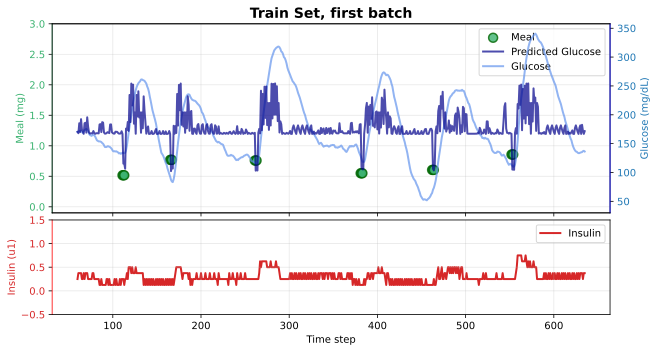

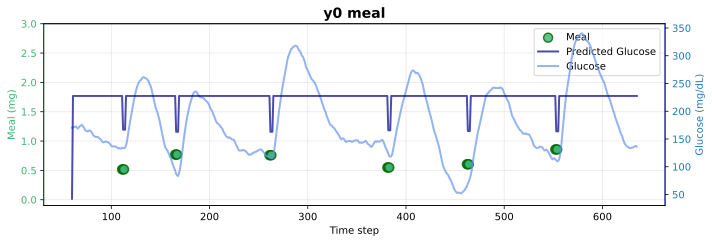

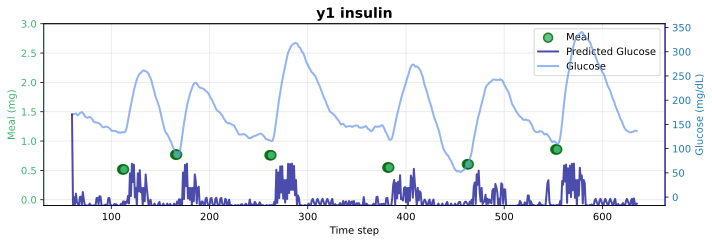

C:\Users\pogotar\AppData\Local\Temp\3\ipykernel_12572\2706193168.py:76: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(G_bar - scaler_glucose.denormalize(y_hat[0,cumulative_window:-horizon,0]).detach().cpu().numpy(), label = "G_bar - scaler_y.denormalize(y_hat)")


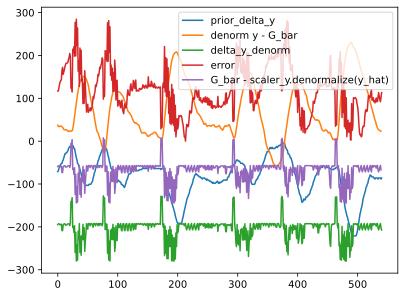

C:\Users\pogotar\AppData\Local\Temp\3\ipykernel_12572\2706193168.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


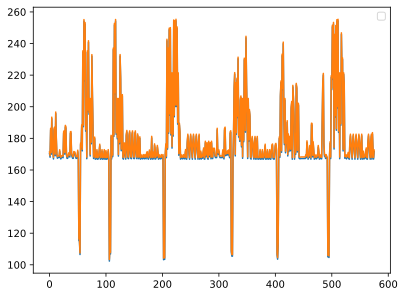

In [ ]:
importlib.reload(models_SSM)
from models_SSM import NonLinearController, NonLinearController_p2, ClosedLoopSystem_SSM, monotonic_gain_loss

# --------------Plot identification result s for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_2" 

MODEL_PATH = Path(patient_model_folder)



# ----------------------------------


SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

Dual_SSM = DualSSM(SSM_0, SSM_1, device=device)
controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
Dual_SSM.load_state_dict(checkpoint["Dual_SSM_state_dict"])

Dual_SSM.eval()

for u0_batch, _, _, u1_batch, y_batch, t_batch in train_loader_p:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
            
    _, y_hat, y0_hat, y1_hat  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality = 1 * monotonic_gain_loss(-y_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                                evaluate = 'insulin', 
                                                cumulative_window = cumulative_window, 
                                                horizon=horizon, 
                                                aggressive_coeff=1, 
                                                CR = loaded_parameters.Patient_par.CR,
                                                CF = loaded_parameters.Patient_par.CF,
                                                G_bar=torch.tensor([110]),
                                                return_debug = True)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    y0_hat_train_np = scaler_glucose.denormalize(y0_hat.detach().cpu()).numpy()
    y1_hat_train_np = scaler_glucose.denormalize(-y1_hat.detach().cpu()).numpy()
    
    time_plot = t_batch.detach().cpu()
    
    break # just first batch

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),  glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(),                                   glucose =y_batch_np[0,:,0],  predicted_glucose=y0_hat_train_np[0,:,0], title=f"y0 meal")

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(),                                   glucose =y_batch_np[0,:,0],  predicted_glucose=y1_hat_train_np[0,:,0], title=f"y1 insulin")


plt.figure(); G_bar = torch.tensor([110]);     cumulative_window = int(cumulative_window); horizon = int(horizon)
a = prior_delta_y[0,:,0].detach().cpu().numpy()
plt.plot(a, label = "prior_delta_y")
plt.plot( scaler_glucose.denormalize(y_batch[0,cumulative_window:-horizon,0]).detach().cpu().numpy() - G_bar.numpy(), label = "denorm y - G_bar")
plt.plot( delta_y_denorm[0,:,0].detach().cpu().numpy(), label = "delta_y_denorm")
plt.plot(500*torch.abs(error[0,:,0]).detach().numpy(), label = "error")
plt.plot(G_bar - scaler_glucose.denormalize(y_hat[0,cumulative_window:-horizon,0]).detach().cpu().numpy(), label = "G_bar - scaler_y.denormalize(y_hat)")
plt.legend()
plt.show()

plt.figure()
plt.plot(y_hat_np[0,:,0])
plt.plot(scaler_glucose.denormalize((y0_hat.detach().cpu()-y1_hat.detach().cpu()))[0,:,0].numpy()+1)
plt.legend()
plt.show()

### Plots: identification results for the negative feedback of S and K

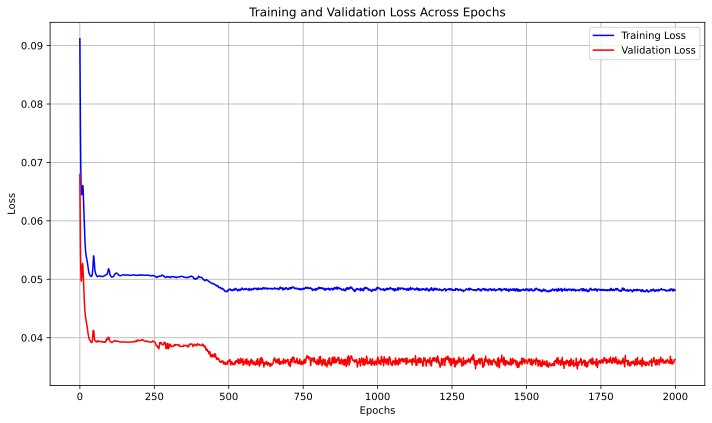

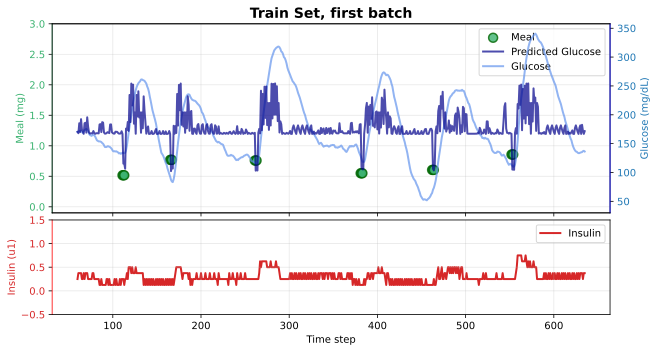

Modificato FIT_SSM_s2_34_s2 (riga 2): 8.755952835083008

✓ File c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients/results_v3.xlsx aggiornato con successo


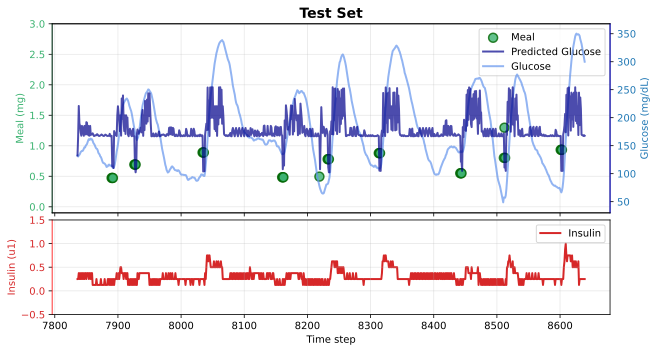

Modificato FIT_SSM_s2_34 (riga 12): 11.342686653137207

✓ File c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients/results_v3.xlsx aggiornato con successo


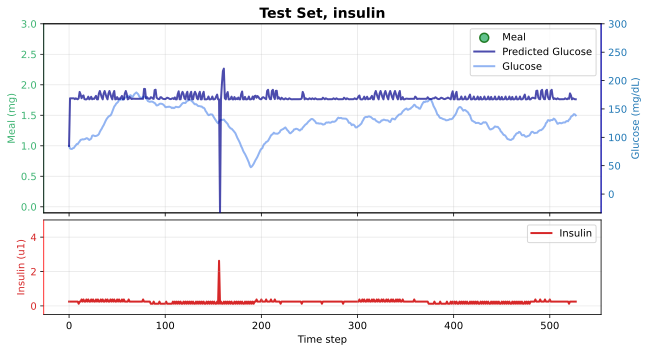

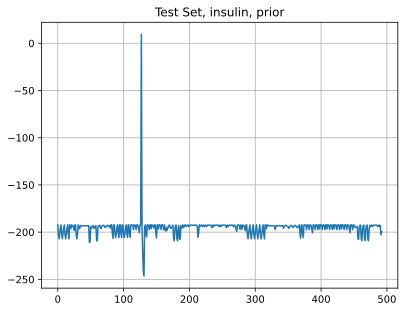

Modificato delta_G_SSM_s2_34 (riga 22): -0.00054931640625
Modificato delta_t_SSM_s2_34 (riga 22): 125

✓ File c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients/results_v3.xlsx aggiornato con successo


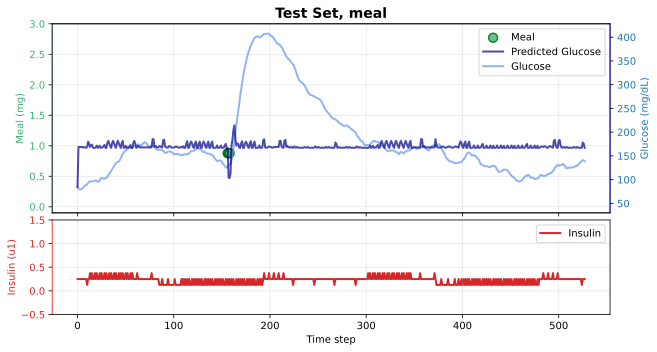

Modificato delta_G_SSM_s2_34 (riga 32): 47.438751220703125
Modificato delta_t_SSM_s2_34 (riga 32): 20

✓ File c:\Users\pogotar\Desktop\Dottorato\Nonlinear_system_identification_modified\Nonlinear_system_identification_diabetic_patients/results_v3.xlsx aggiornato con successo


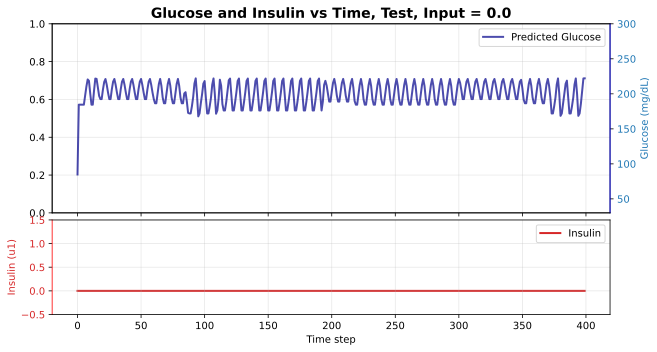

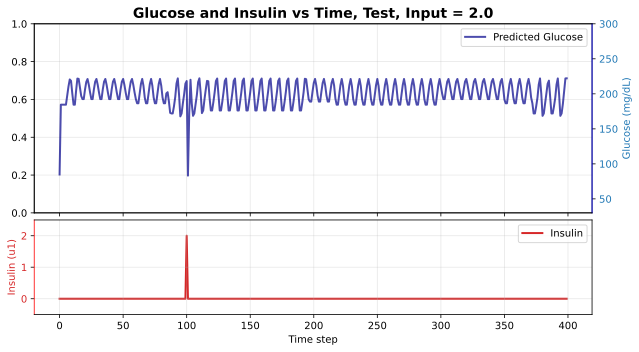

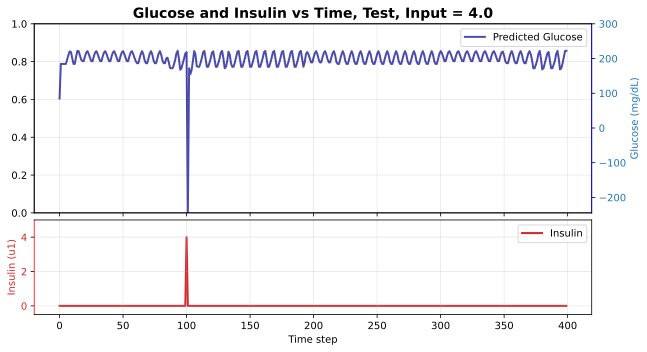

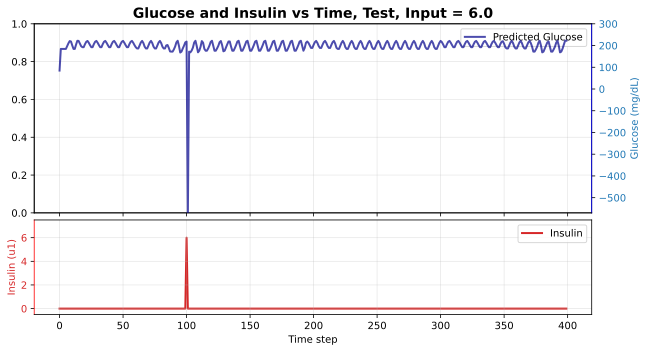

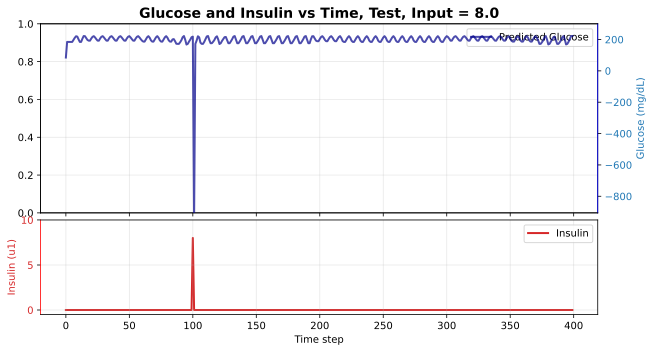

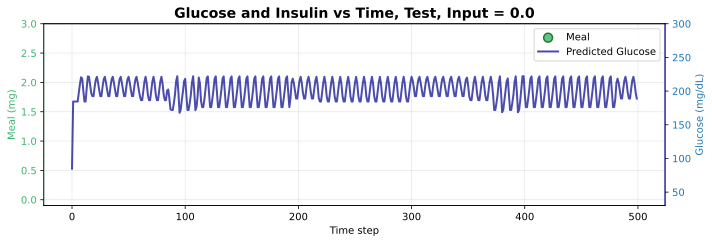

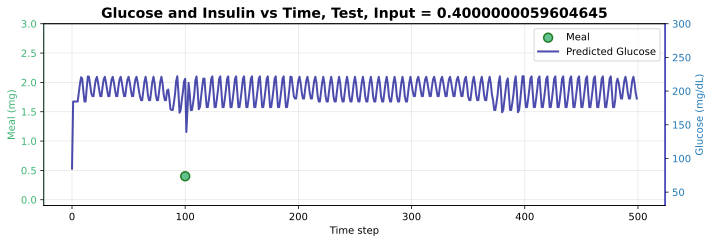

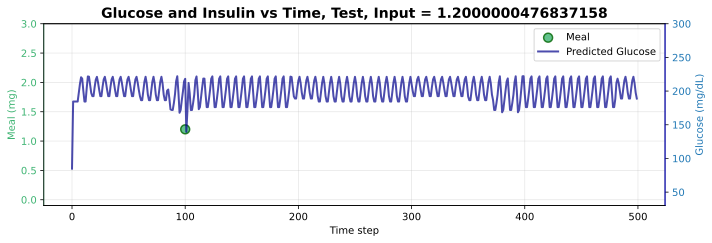

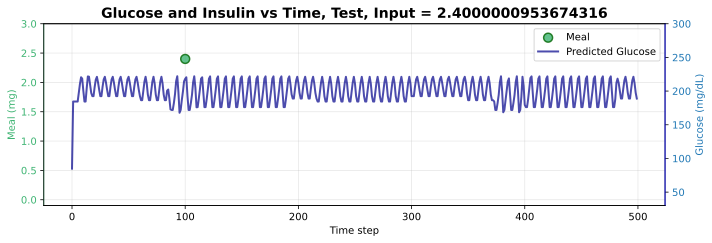

In [ ]:
# --------------Plot identification results for G-----------------

patient_str = "/paz_" + str(int(patient)).zfill(3)
patient_model_folder = model_folder + "/" + patient_str + "/" + "strategy_2"
MODEL_PATH = Path(patient_model_folder)
PARAM_PATH = MODEL_PATH / "params" / "parameters.mat"
params = scipy.io.loadmat(PARAM_PATH)

x0          = torch.tensor(params['x0'])
input_dim   = params["input_dim"].flatten().astype(int).tolist()
output_dim  = params["output_dim"].flatten().astype(int).tolist()
dim_internal= params["dim_internal"].flatten().astype(int).tolist()
dim_nl      = params["dim_nl"].flatten().astype(int).tolist()

y_init      = torch.tensor(params['y_init'])
gamma       = torch.tensor(params['gamma']).flatten()

train_losses = params["train_losses"][0]
val_losses   = params["val_losses"][0]
epoch_best   = int(params["epoch_when_model_saved"][0].item())

# epochs = 200

# ----------------------------------

#Training and Validation Loss Across Epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epochs_s2), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs_s2), val_losses, label='Validation Loss', color='red')  # Assuming val_losses are collected
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss Across Epochs')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


# ----------------------------------

SSM_0 = DeepSSM(d_input=input_dim[0], d_output=output_dim[0], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)
SSM_1 = DeepSSM(d_input=input_dim[1], d_output=output_dim[1], d_model = 8, d_state=8, n_layers = 7, ff='GLU', param='l2n',
                    max_phase_b=0.04,  d_hidden=12, dim_amp=3)

Dual_SSM = DualSSM(SSM_0, SSM_1, device=device)
controller = NonLinearController_p2(loaded_parameters, PID_functions, dataset.basal_vec, scaler_glucose, scaler_insulin, scaler_meal, use_noise = use_noise)
closed_loop_SSM = ClosedLoopSystem_SSM(Dual_SSM, controller, negative=True)

checkpoint = torch.load(MODEL_PATH / "trained_models.pth", map_location="cpu")
Dual_SSM.load_state_dict(checkpoint["Dual_SSM_state_dict"])

Dual_SSM.eval()

scenarios = {'train_batch_1': 0, 'test_similar_to_train': 1, 'insulin_impulse': 2, 'meal_impulse': 3}

# --------------Plot identification results for G-----------------

tot_FIT = []
for u0_batch, _, _, u1_batch, y_batch, t_batch in train_loader_p:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(train_loader_p, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
            
    _, y_hat_train, _, _  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat_train.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
    for i in range(y_batch_np.shape[0]):  # itera su 12 batch
        fit_val = FIT_formula(y_true=y_batch_np[i,:,0], y_hat=y_hat_np[i,:,0])
        tot_FIT.append(fit_val)
    

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Train Set, first batch")


median_FIT = np.median(np.vstack(tot_FIT).flatten())

row = 1 + scenarios['train_batch_1'] * 10 + patient

modifiche = {
    f'FIT_SSM_s2_{exp_identifier}_s2': {
        row : median_FIT,
    },
}
modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


# ---------------------------------------------------------------


for u0_batch, _, _, u1_batch, y_batch, t_batch in test_loader:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(t_batch) # batch_size, time_horizon, input_dim
    u0_batch, u1_batch, y_batch, t_batch = u0_batch.to(device), u1_batch.to(device), y_batch.to(device), t_batch.to(device)
    
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat_val, _, _  = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  


    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat_val.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set")


FIT = FIT_formula(y_true = y_batch_np[0,:,0], y_hat = y_hat_np[0,:,0])
row = 1 + scenarios['test_similar_to_train'] * 10 + patient

modifiche = { 
    f'FIT_SSM_s2_{exp_identifier}': {
        row : FIT,
    },
}
modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


# -------------------------------------------------------------


data_path = f'{root}/data/test/sc_1_day_test_IR_insulin_30g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')

# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

# --- Creazione di un Dataset custom ---
class TestDataset(Dataset):
    def __init__(self, MH, I, y, sequence_length=1):
        """
        MH: meal input (torch tensor)
        I: insulin input (torch tensor)
        y: output (glucose) (torch tensor)
        sequence_length: lunghezza sequenza temporale per la RNN/REN
        """
        self.MH = MH.unsqueeze(-1) if MH.ndim==1 else MH  # shape (N,1)
        self.I  = I.unsqueeze(-1) if I.ndim==1 else I
        self.y  = y.unsqueeze(-1) if y.ndim==1 else y
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.y) - self.seq_len + 1

    def __getitem__(self, idx):
        u0_seq = self.MH[idx:idx+self.seq_len]
        u1_seq = self.I[idx:idx+self.seq_len]
        y_seq  = self.y[idx:idx+self.seq_len]
        time_seq = torch.arange(idx, idx+self.seq_len)
        return u0_seq, u1_seq, y_seq, time_seq


test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader_new, loaded_parameters, scaler_glucose, scaler_insulin, dataset) #probabilmente cambiare dataset
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat, y0_hat, y1_hat = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  
    
    loss_batch_I, delta_y_denorm, prior_delta_y, error, penality = 1 * monotonic_gain_loss(-y_hat, u1_batch, scaler_glucose, scaler_insulin, y_batch, 
                                            evaluate = 'insulin', 
                                            cumulative_window = cumulative_window, 
                                            horizon=horizon, 
                                            aggressive_coeff=1, 
                                            CR = loaded_parameters.Patient_par.CR,
                                            CF = loaded_parameters.Patient_par.CF,
                                            G_bar=torch.tensor([110]),
                                            return_debug = True)

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u1_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_min_value, y_min_index = torch.min(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_min_index = y_min_index.item() + u_max_index.item()
    # guarda min da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_when_u_max) - scaler_glucose.denormalize(y_min_value) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_min_index - u_max_index.item()) * 5  # in minuti

plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, insulin")
plt.figure()
plt.plot(delta_y_denorm[0,:,0].detach().cpu().numpy())
plt.title("Test Set, insulin, prior")
plt.grid(); plt.show()

# scenario	patients	delta_G_empiric	 delta_G_101_linearized 	delta_G_formula 	delta_G_SSM  delta_t_max	FIT_101_linearized	FIT_SSM

row = 1 + scenarios['insulin_impulse'] * 10 + patient

modifiche = {
    f'delta_G_SSM_s2_{exp_identifier}': {
        row : delta_G_SSM,
    },
    f'delta_t_SSM_s2_{exp_identifier}': {
        row : delta_t_SSM,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)


# -------------------------------------------------------------

data_path = f'{root}/data/test/sc_1_day_test_IR_meal_80g_13h/'

loaded = sio.loadmat(f'{data_path}/s#adult#{patient:03d}.mat')



# Insulin suggestions saturated (effectively given by the pump)
I_data = loaded['injection']['signals'][0, 0]['values'][0, 0][1::5] / 6000  # now in U
I_data = I_data[:,0]
i = scaler_insulin.normalize(torch.from_numpy(I_data).float())
CGM = loaded['CGM']['signals'][0, 0]['values'][0, 0][1::5].flatten()
y = scaler_glucose.normalize(torch.from_numpy(CGM).float())
true_carbs_hypo_redone_05 = loaded['carb_intake']['signals'][0, 0]['values'][0, 0][1:-1:2].flatten()
MH = true_carbs_hypo_redone_05.reshape(-1, 5).sum(axis=1)
m = scaler_meal.normalize(torch.from_numpy(MH).float())

test_dataset_new = TestDataset(MH=m, I=i, y=y, sequence_length=len(y))
test_loader_new = DataLoader(test_dataset_new, batch_size=1, shuffle=False)


for u0_batch, u1_batch, y_batch, time in test_loader_new:

    u0_batch, u1_batch, y_batch, t_batch = ensure_3d(u0_batch), ensure_3d(u1_batch), ensure_3d(y_batch), ensure_3d(time)
    u_batch = torch.cat((u0_batch, u1_batch), dim=2)  # concatenate along input di
    
    
    saturation_error_init, glucose_PID_init, _ = fun_start_controller(test_loader_new, loaded_parameters, scaler_glucose, scaler_insulin, dataset)
    closed_loop_SSM.reset(y0 = y_batch[:,:1,:1], saturation_error_init = saturation_error_init, glucose_PID_init = glucose_PID_init)
    
    _, y_hat, _, _ = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_batch_np = scaler_glucose.denormalize(y_batch.detach().cpu()).numpy()
    y_hat_np = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()
    time_plot = t_batch.detach().cpu()
    
    u_max_value, u_max_index = torch.max(u0_batch, dim=1)
    y_when_u_max = y_hat[0, u_max_index.item()-1, 0]
    y_max_value, y_max_index = torch.max(y_hat[0,u_max_index+3:u_max_index+12*6,0], dim = 0) 
    y_max_index = y_max_index.item() + u_max_index.item()
    # guarda max da quando ho impulso fino a 6 ore in avanti
    delta_G_SSM = scaler_glucose.denormalize(y_max_value) - scaler_glucose.denormalize(y_when_u_max) 
    delta_G_SSM = delta_G_SSM.item()
    delta_t_SSM = (y_max_index - u_max_index.item()) * 5  # in minuti


plot_glucose_insulin(time_plot[0,:,0].numpy(),meal = u0_batch[0,:,0].numpy(), insulin=u1_batch[0,:,0].numpy(),glucose =y_batch_np[0,:,0],  predicted_glucose=y_hat_np[0,:,0], title=f"Test Set, meal")
    
row = 1 + scenarios['meal_impulse'] * 10 + patient

modifiche = {
    f'delta_G_SSM_s2_{exp_identifier}': {
        row : delta_G_SSM,
    },
    f'delta_t_SSM_s2_{exp_identifier}': {
        row : delta_t_SSM,
    }
}

modify_xlsx_row_and_column(f'{root}/results_v3.xlsx', modifiche)



# ------------------------- fake insulin ------------------------------------

fake_insulins = [0, 2, 4, 6, 8]

for sample in  fake_insulins:

    Sim_time = 2000
    Ts = 5
    fake_time = np.arange(0, Sim_time, Ts)

    fake_meal = np.zeros(Sim_time//Ts)
    fake_meal = torch.from_numpy(fake_meal).float()

    fake_insulin = np.zeros(Sim_time//Ts)
    fake_insulin[100] = sample
    fake_insulin = torch.from_numpy(fake_insulin).float()
    
    t_batch = torch.arange(0, len(fake_insulin))
    
    t_batch = t_batch[None,:, None]
    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    
    u_batch = torch.cat((fake_meal, fake_insulin), dim=2)
    
    closed_loop_SSM.reset()
    _, y_hat, _, _ = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    plot_glucose_insulin(t_batch[0,:,0].numpy(), insulin=fake_insulin[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_insulin[0,100,0].numpy()}")



# ------------------------- fake meal ------------------------------------

fake_meals = [0, 0.4, 0.4*3, 0.4*6]

for sample in  fake_meals:
    fake_meal = np.zeros(500)
    fake_meal[100] = sample
    fake_meal = torch.from_numpy(fake_meal).float()
    fake_insulin = np.zeros(500)
    fake_insulin = torch.from_numpy(fake_insulin).float()

    t_batch = torch.arange(0, len(fake_insulin))
    
    t_batch = t_batch[None,:, None]
    fake_meal = fake_meal[None,:, None];   fake_insulin = fake_insulin[None,:, None]
    SSM_0.eval();                          SSM_1.eval()
    
    
    u_batch = torch.cat((fake_meal, fake_insulin), dim=2)
    
    closed_loop_SSM.reset()
    _, y_hat, _, _ = closed_loop_SSM(u_batch, t_batch, y_t0 = y_batch[:,:1,:1])  

    y_fake = scaler_glucose.denormalize(y_hat.detach().cpu()).numpy()

    plot_glucose_insulin(t_batch[0,:,0].numpy(), meal=fake_meal[0,:,0].numpy(), predicted_glucose=y_fake[0,:,0], title=f"Glucose and Insulin vs Time, Test, Input = {fake_meal[0,100,0].numpy()}")




